# Project Title: Predicting Bike-Sharing Demand: A Weather-Driven Analysis for Capital Bikeshare

Fall24 SI618 Group 17

School of Information, University of Michigan

## Team Members
* Yidan Chang (yidanydc)
* Zhuxin Wu (zhuxinwu)
* Shangqing Wei (weishq)

# Part II: Analysis

## Descriptive Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and drop the columns `start_lat`, `start_lng`, `end_lat`, `end_lng` which are not used in current analysis
# the dataset combined with datasets `Daily rent data`, `Station list` and `Usage frequency`
df_rent = pd.read_csv('detail_frequency.csv').drop(columns=['ride_id','start_lat','start_lng','end_lat','end_lng']).reset_index(drop=True)

In [2]:
df_rent.head()

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,started_day,pickup_counts,dropoff_counts
0,docked_bike,2023-05-12 18:57:59,2023-05-12 19:17:50,3rd & Tingey St SE,31634,8th & F St NE,31631,casual,2023-05-12,50.0,54.0
1,classic_bike,2023-05-23 07:55:29,2023-05-23 08:11:12,Clarendon Blvd & Pierce St,31016,15th & L St NW,31276,member,2023-05-23,14.0,45.0
2,electric_bike,2023-05-05 17:27:10,2023-05-05 17:40:17,South Capitol St and Southern Ave SE,31830,Tanger Outlets,32415,member,2023-05-05,2.0,6.0
3,classic_bike,2023-05-09 11:22:05,2023-05-09 11:35:11,11th & O St NW,31286,19th St & Pennsylvania Ave NW,31100,member,2023-05-09,53.0,17.0
4,classic_bike,2023-05-06 10:24:09,2023-05-06 10:35:13,11th & O St NW,31286,16th & Harvard St NW,31135,casual,2023-05-06,67.0,56.0


In [3]:
df_rent['started_at'] = pd.to_datetime(df_rent['started_at'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
df_rent['ended_at'] = pd.to_datetime(df_rent['ended_at'], format="%Y-%m-%d %H:%M:%S", errors='coerce')
df_rent['duration'] = (df_rent['ended_at'] - df_rent['started_at']).dt.total_seconds() 
df_rent['started_day'] = pd.to_datetime(df_rent['started_day'])
df_rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009164 entries, 0 to 4009163
Data columns (total 12 columns):
 #   Column              Dtype         
---  ------              -----         
 0   rideable_type       object        
 1   started_at          datetime64[ns]
 2   ended_at            datetime64[ns]
 3   start_station_name  object        
 4   start_station_id    int64         
 5   end_station_name    object        
 6   end_station_id      int64         
 7   member_casual       object        
 8   started_day         datetime64[ns]
 9   pickup_counts       float64       
 10  dropoff_counts      float64       
 11  duration            float64       
dtypes: datetime64[ns](3), float64(3), int64(2), object(4)
memory usage: 367.1+ MB


In [4]:
df_weather = pd.read_csv('weather_frequency.csv', usecols=['date', 'temp', 'icon'])
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather = df_weather.drop_duplicates().reset_index(drop=True)
df_weather.info()
weather = df_weather[['date', 'temp', 'icon', 'temp']].copy()
weather['date'] = pd.to_datetime(weather['date'])
weather.rename(columns={'icon': 'weather'}, inplace=True)
weather

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    367 non-null    datetime64[ns]
 1   temp    367 non-null    float64       
 2   icon    367 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 8.7+ KB


,date,temp,weather,temp
0,2023-05-01,13.7,rain,13.7
1,2023-05-02,11.9,cloudy,11.9
2,2023-05-03,11.0,rain,11.0
3,2023-05-04,12.7,partly-cloudy-day,12.7
4,2023-05-05,15.0,partly-cloudy-day,15.0
...,...,...,...,...
362,2024-04-27,13.2,rain,13.2
363,2024-04-28,19.5,partly-cloudy-day,19.5
364,2024-04-29,24.0,partly-cloudy-day,24.0
365,2024-04-30,23.3,rain,23.3


In [5]:
df = df_rent.merge(df_weather, left_on='started_day', right_on='date', how='left').drop(columns=['date'])
df = df.drop(columns=['started_day']).reset_index(drop=True)

In [6]:
rides_per_day = pd.DataFrame(df['started_at'].dt.date.value_counts().sort_index().reset_index())
rides_per_day.columns = ['date','rides_counts']
rides_per_day['date'] = pd.to_datetime(rides_per_day['date'])
rides_per_day = rides_per_day.merge(weather, left_on='date', right_on='date', how='left')
rides_per_day['rides_counts'] = rides_per_day['rides_counts'].astype(int)
rides_per_day = rides_per_day.loc[:, ~rides_per_day.columns.duplicated()]

In [7]:
# Calculate statistics for relevant features
numeric_features = ['pickup_counts', 'dropoff_counts', 'duration', 'temp']
statistics = []

# Function to calculate descriptive statistics for a feature
def descriptive_analysis(df, feature):
    mean_value = df[feature].mean().round(2)
    median_value = df[feature].median()
    mode_value = df[feature].mode()[0]
    range_value = df[feature].max() - df[feature].min()
    variance_value = df[feature].var()
    std_dev_value = df[feature].std().round(2)
    min_value = df[feature].min()
    max_value = df[feature].max()
    percentile_25 = df[feature].quantile(0.25)
    percentile_75 = df[feature].quantile(0.75)
    return [feature, mean_value, median_value, mode_value, range_value, variance_value, std_dev_value, min_value, percentile_25, percentile_75, max_value]

rides_per_day_descriptive = descriptive_analysis(rides_per_day, 'rides_counts')
for feature in numeric_features:
    statistics.append(descriptive_analysis(df, feature))

statistics.insert(0, rides_per_day_descriptive)

# Create a DataFrame for the statistics
stats_df = pd.DataFrame(statistics, columns=['Feature', 'Mean', 'Median', 'Mode', 'Range', 'Variance', 'Standard Deviation', 'Min', '25%', '75%', 'Max'])
stats_df

,Feature,Mean,Median,Mode,Range,Variance,Standard Deviation,Min,25%,75%,Max
0,rides_counts,10954.00,11751.0,7326.0,16008.0,1.137915e+07,3373.30,1737.0,8633.25,13601.0,17745.0
1,pickup_counts,50.03,43.0,37.0,374.0,1.313720e+03,36.25,1.0,24.00,68.0,375.0
2,dropoff_counts,50.40,44.0,43.0,373.0,1.339005e+03,36.59,0.0,24.00,68.0,373.0
3,duration,1050.32,628.0,298.0,2943356.0,1.733992e+07,4164.12,-4077.0,366.00,1087.0,2939279.0
4,temp,17.33,18.6,23.0,35.0,5.777028e+01,7.60,-5.0,11.40,23.7,30.0


### Overall Descriptive Analysis Summary

1. **rides_counts**:
   - The average daily ride count is **10,954**, with a median of **11,751**. The mode is **7,326**, indicating this value occurred most frequently.
   - The **range** of ride counts is **16,008** (min: **1,737**, max: **17,745**), with a **standard deviation** of **3,373.3**, suggesting a high level of fluctuation in daily ride counts.

2. **pickup_counts & dropoff_counts**:
   - Both features have similar statistics: average **~50**, median **~44**, and mode **~43**.
   - The **range** is **374** for pickups and **373** for dropoffs, indicating substantial variation, with a **standard deviation** of **~36**, showing moderate variability across different days.

3. **duration (in seconds)**:
   - The average duration is **1,050.32** (seconds), with a median of **628**. The mode is **298**.
   - There is a significant **range** of **2,943,356**, with a **minimum value of -4,077** indicating potential data errors. The high **standard deviation** of **4,164.12** points to considerable variability, suggesting the presence of outliers.

4. **temp (temperature)**:
   - The average temperature is **17.33°C**, with a median of **18.6°C** and a mode of **23°C**.
   - The **range** is **35°C** (min: **-5°C**, max: **30°C**), with a **standard deviation** of **7.60**, indicating moderate variability in temperature over the observed period.


In [8]:
# Create a new column 'day_of_week' that identifies the day of the week
rides_per_day['day_of_week'] = pd.to_datetime(rides_per_day['date']).dt.day_name()
# Perform a groupby operation to get descriptive statistics for each day of the week
day_of_week_stats = rides_per_day.groupby('day_of_week')['rides_counts'].describe().sort_values(by='mean', ascending=False)
day_of_week_stats

,count,mean,std,min,25%,50%,75%,max
day_of_week,,,,,,,,
Saturday,52.0,11505.019231,4231.928173,2178.0,9267.00,12134.0,14763.00,17745.0
Thursday,52.0,11465.480769,2776.389061,4691.0,9498.50,11936.0,13566.00,15171.0
Friday,52.0,11173.173077,2959.454214,1770.0,9149.25,11740.5,13613.00,15078.0
Wednesday,52.0,11172.288462,3409.923876,1737.0,8177.50,13069.0,13843.00,14730.0
Tuesday,53.0,10987.641509,3565.131210,1979.0,8459.00,12146.0,13675.00,17629.0
Sunday,52.0,10467.057692,3610.647970,3017.0,7483.25,11700.0,13299.25,16667.0
Monday,53.0,9926.452830,2698.603261,2209.0,8045.00,10800.0,12018.00,13401.0


### Descriptive Analysis of Ride Counts by Day of the Week

1. **Saturday**:
   - Highest average ride count of **11,505**, with a median of **12,134** and a maximum of **17,745**.
   - High variability (Std: **4,231.93**), with ride counts ranging from **2,178** to **17,745**. This suggests that Saturdays have the most fluctuations in usage, possibly influenced by weather, events, or leisure activities.

2. **Thursday**:
   - Average ride count is **11,465**, with a median of **11,936** and a maximum of **15,171**.
   - The lower standard deviation (**2,776.39**) compared to Saturday indicates more consistent ride usage on Thursdays.

3. **Friday**:
   - Average ride count is **11,173**, with a median of **11,740.5** and a maximum of **15,078**.
   - Moderate variability (Std: **2,959.45**), indicating fairly steady ride activity, possibly influenced by commuters and end-of-week activities.

4. **Wednesday**:
   - Average ride count is **11,172**, with a median of **13,069** and a maximum of **14,730**.
   - The standard deviation (**3,409.92**) suggests moderate fluctuation, similar to other mid-week days.

5. **Tuesday**:
   - Average ride count of **10,987**, with a median of **12,146** and a maximum of **17,629**.
   - The standard deviation is relatively high (**3,565.13**), suggesting noticeable variability, likely driven by factors such as commuting patterns.

6. **Sunday**:
   - Average ride count is **10,467**, with a median of **11,700** and a maximum of **16,667**.
   - The standard deviation (**3,610.65**) indicates that ride counts vary considerably, possibly due to changes in leisure activities or weather conditions.

7. **Monday**:
   - Lowest average ride count of **9,926**, with a median of **10,800** and a maximum of **13,401**.
   - The lowest standard deviation (**2,698.60**) suggests that Mondays have the most consistent ride counts, likely due to regular commuting patterns.

Overall, **Saturday** shows the highest average and the greatest variability, possibly driven by varying weekend activities. **Monday** has the lowest average and the most consistent ride counts, indicating more predictable commuter usage. These trends highlight the different factors influencing bike-sharing demand across the week, such as commuting versus leisure activities.


In [9]:
rides_per_day['month'] = pd.to_datetime(rides_per_day['date']).dt.strftime('%B')
# Perform a groupby operation to get descriptive statistics for each month
month_stats = rides_per_day.groupby('month')['rides_counts'].describe().sort_values(by='mean', ascending=False)
month_stats

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
July,31.0,13146.258065,1406.573140,11158.0,12215.00,12743.0,13912.00,17629.0
August,31.0,13126.419355,1570.935003,8731.0,12008.00,13528.0,14313.00,15670.0
October,31.0,13087.096774,1937.167681,6450.0,11859.00,13675.0,14463.50,16636.0
April,30.0,12817.733333,2551.506207,5305.0,11781.25,13231.0,14561.75,17479.0
September,30.0,12766.966667,2602.775872,3127.0,11501.00,13487.0,14246.00,16209.0
June,30.0,12554.100000,2155.898634,5659.0,11461.25,13242.5,13894.50,15373.0
May,31.0,12231.516129,1753.191012,6744.0,11441.50,13111.0,13466.50,14641.0
March,31.0,10925.258065,3097.933053,3414.0,8720.50,11334.0,12915.00,17745.0
November,30.0,9569.333333,3034.307583,2618.0,7585.75,10197.0,11720.50,15039.0


### Monthly Ride Counts Analysis

1. **Highest Average Ride Counts**:
   - **July** has the highest average ride count of **13,146**, followed closely by **August** (**13,126**) and **October** (**13,087**). These months are characterized by warm weather, which likely encourages more people to use bike-sharing services for both leisure and commuting.
   - The standard deviation for July is **1,406.57**, indicating consistent demand during the peak summer season, while August's standard deviation is slightly higher (**1,570.94**), suggesting a bit more fluctuation.

2. **Mid-Level Average Ride Counts**:
   - **April** (**12,817**), **September** (**12,766**), **June** (**12,554**), and **May** (**12,231**) also have relatively high average counts, suggesting spring and early fall are popular times for biking. The temperatures during these months are usually moderate, making it comfortable for cycling.
   - The variability is slightly higher for April and September, with standard deviations around **2,551.51** and **2,602.78**, respectively, indicating a wider spread in usage during these transitional seasons.

3. **Lower Average Ride Counts**:
   - **March** (**10,925**), **November** (**9,569**), and **February** (**8,460**) show a noticeable drop in average ride counts. These months are associated with colder or transitioning weather, which may deter some users.
   - November and March show relatively high standard deviations (**~3,000**), indicating more inconsistency, possibly due to fluctuating temperatures or holidays.

4. **Lowest Average Ride Counts**:
   - **December** (**6,847**) and **January** (**5,880**) have the lowest ride counts, as expected during winter months when cold temperatures and potential snow make biking less appealing.
   - The standard deviation for December and January is **~2,500**, indicating moderate consistency in ride counts, possibly due to predictably lower usage during the winter.

**Seasonal Influence**:
The trend clearly shows that **weather and season** are key factors influencing bike-sharing demand. Warmer months (July, August, September) and moderate spring/fall months see higher average ride counts, while winter months see significantly lower numbers. This aligns with expectations that people are more inclined to use bike-sharing services during comfortable weather conditions.

### Ride counts by weather 

In [10]:
rides_per_day.groupby('weather')['rides_counts'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
partly-cloudy-day,189.0,11826.280423,2912.761279,3242.0,9763.0,12865.0,14015.0,17745.0
cloudy,7.0,10890.000000,3627.685396,7125.0,7952.5,9428.0,13781.5,16209.0
clear-day,26.0,10809.230769,3609.817528,3017.0,8595.5,11493.5,13632.0,15966.0
rain,137.0,10165.481752,3320.372942,1737.0,7584.0,11158.0,12339.0,17629.0
snow,7.0,3436.571429,2202.562361,1770.0,2078.5,2209.0,4323.0,7274.0


**Summary**:
- The weather data shows that **partly cloudy** and **rainy** conditions are the most prevalent in Washington, D.C., while **clear**, **cloudy**, and **snowy** days are relatively infrequent.
- **Partly cloudy days** see the highest average ride counts, suggesting comfortable conditions for biking.
- **Rainy and cloudy days** exhibit variability, likely due to the unpredictability of how severe the weather is, with reduced average rides compared to partly cloudy days.
- **Snowy days** have the lowest ride counts, indicating that adverse weather conditions significantly impact biking behavior.
- These insights highlight how weather conditions can strongly influence bike-sharing usage, with **pleasant weather** leading to higher usage and **adverse weather** resulting in a considerable drop in demand.

## Inferential Statistics

In [11]:
df.head()

,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,member_casual,pickup_counts,dropoff_counts,duration,temp,icon
0,docked_bike,2023-05-12 18:57:59,2023-05-12 19:17:50,3rd & Tingey St SE,31634,8th & F St NE,31631,casual,50.0,54.0,1191.0,21.8,partly-cloudy-day
1,classic_bike,2023-05-23 07:55:29,2023-05-23 08:11:12,Clarendon Blvd & Pierce St,31016,15th & L St NW,31276,member,14.0,45.0,943.0,19.5,partly-cloudy-day
2,electric_bike,2023-05-05 17:27:10,2023-05-05 17:40:17,South Capitol St and Southern Ave SE,31830,Tanger Outlets,32415,member,2.0,6.0,787.0,15.0,partly-cloudy-day
3,classic_bike,2023-05-09 11:22:05,2023-05-09 11:35:11,11th & O St NW,31286,19th St & Pennsylvania Ave NW,31100,member,53.0,17.0,786.0,17.7,rain
4,classic_bike,2023-05-06 10:24:09,2023-05-06 10:35:13,11th & O St NW,31286,16th & Harvard St NW,31135,casual,67.0,56.0,664.0,16.7,partly-cloudy-day


### Regression Analysis I
### Null and Alternative Hypotheses

- **Null Hypothesis ($ H_0 $)**: There is no relationship between temperature and ride counts. In statistical terms, this means that the slope coefficient of `temp` in the regression model is zero.
  
  $
  H_0: \beta_{\text{temp}} = 0
  $

  This implies that changes in temperature have no effect on the predicted ride counts.

- **Alternative Hypothesis ($ H_1 $)**: There is a significant relationship between temperature and ride counts. This means that the slope coefficient of `temp` is not zero.

  $
  H_1: \beta_{\text{temp}} \neq 0
  $

  This implies that changes in temperature do affect the predicted ride counts.

### Significance Level
To test these hypotheses, a common significance level ($ \alpha $) is 0.05. If the p-value associated with `temp` is less than 0.05, we would reject the null hypothesis, concluding that temperature has a significant effect on ride counts.


In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
model0 = smf.ols("rides_counts ~ temp", data=rides_per_day).fit()
model0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           rides_counts   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     347.7
Date:                Tue, 05 Nov 2024   Prob (F-statistic):           5.98e-55
Time:                        01:32:49   Log-Likelihood:                -3369.4
No. Observations:                 366   AIC:                             6743.
Df Residuals:                     364   BIC:                             6751.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6488.2332    270.740     23.965      0.000    5955.823    7020.643
temp         286.8247     15.382     18.647      0.000     256.576     317.073
==============================================================================
Omnibus:                       16.511   Durbin-Watson:                   1.044
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.701
Skew:                          -0.485   Prob(JB):                     0.000143
Kurtosis:                       3.467   Cond. No.                         37.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

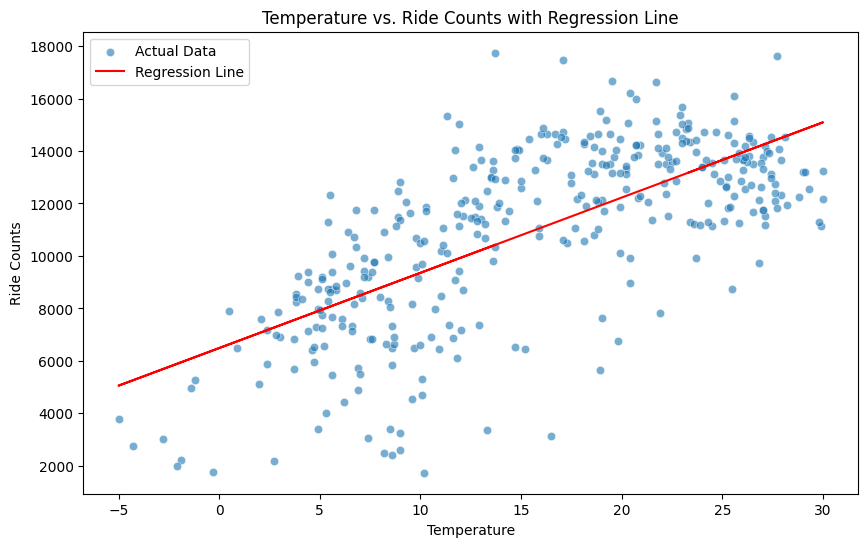

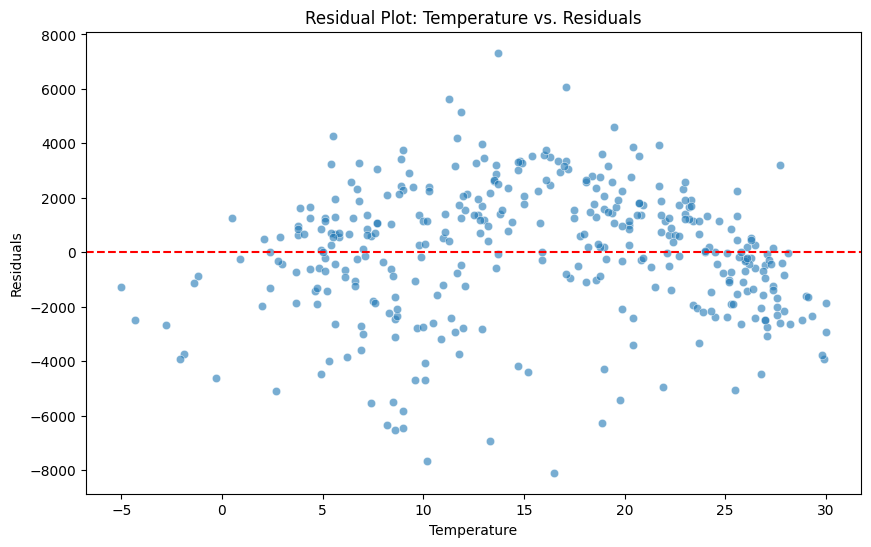

In [13]:
# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='rides_counts', data=rides_per_day, alpha=0.6, label='Actual Data')
plt.plot(rides_per_day['temp'], model0.predict(rides_per_day[['temp']]), color='red', label='Regression Line')
plt.xlabel("Temperature")
plt.ylabel("Ride Counts")
plt.title("Temperature vs. Ride Counts with Regression Line")
plt.legend()
plt.show()

# Residual plot
plt.figure(figsize=(10, 6))
residuals = rides_per_day['rides_counts'] - model0.predict(rides_per_day[['temp']])
sns.scatterplot(x=rides_per_day['temp'], y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Temperature")
plt.ylabel("Residuals")
plt.title("Residual Plot: Temperature vs. Residuals")
plt.show()

### Conclusion
The regression model indicates a significant positive relationship(p-value=5.98e-55) between temperature and ride count. Temperature is a significant predictor, explaining roughly 49% of the variation in ride counts. However, residual diagnostics suggest potential non-normality, which might warrant further investigation if precise predictive accuracy is required.

### Regression Analysis II
### Null and Alternative Hypotheses

- **Null Hypothesis (\( H_0 \))**: There is no correlation between temperature and duration. Mathematically, this implies that the slope (\( \beta \)) of `temp` in the regression model is zero.

  $
  H_0 : \beta_{\text{temp}} = 0
  $

- **Alternative Hypothesis (\( H_1 \))**: There is a correlation between temperature and duration, meaning the slope (\( \beta \)) of `temp` is not zero.

  $
  H_1 : \beta_{\text{temp}} \neq 0
  $

### Choose Significance Level

- **Significance Level $ (\alpha) $**: We’ll use a common significance level of 0.05. If the p-value for `temp` is below 0.05, we’ll reject the null hypothesis and conclude that temperature has a significant effect on duration.


In [14]:
model1 = smf.ols("duration ~ temp", data=df).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duration   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3242.
Date:                Tue, 05 Nov 2024   Prob (F-statistic):               0.00
Time:                        01:32:50   Log-Likelihood:            -3.9101e+07
No. Observations:             4009164   AIC:                         7.820e+07
Df Residuals:                 4009162   BIC:                         7.820e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    780.3645      5.177    150.743      0.000     770.218     790.511
temp          15.5736      0.274     56.940      0.000      15.037      16.110
================================================================================
Omnibus:                 21263392.892   Durbin-Watson:                     1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   2779991585425431.000
Skew:                         266.185   Prob(JB):                           0.00
Kurtosis:                  129005.092   Cond. No.                           47.2
================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Conclusion
In this case, we reject the null hypothesis because the p-value for the temp coefficient is 0.000, which is below the typical significance level of 0.05. This means there is statistically significant evidence to suggest that temperature has an effect on duration.

However, while the effect is statistically significant, the practical significance is minimal due to the very low R-squared value (0.001), which indicates that temperature explains only 0.1% of the variation in duration. In other words, although temperature has a measurable effect on duration, it explains only a tiny fraction of its variance, so temperature alone is not a strong predictor of duration in this dataset. We need to pay attention for this discovery.

### Chi-squre Analysis
### Null and Alternative Hypotheses

- **Null Hypothesis ($ H_0 $)**: There is no association between `rideable_type` and `start_station_name`. In other words, the distribution of bike types (docked, classic, electric) is independent of the start station used by the user.

- **Alternative Hypothesis ($ H_1 $)**: There is an association between `rideable_type` and `start_station_name`. This implies that the choice of bike type varies depending on the start station used by the user.

### Choose a Significance Level

- **Significance Level ($ \alpha $)**: We’ll use a commonly accepted significance level of 0.05. This means that we will reject the null hypothesis if the p-value is less than 0.05, suggesting a statistically significant association between `rideable_type` and `start_station_name`.


In [15]:
# convert the rideable_type and member_casual columns to string
df['rideable_type'] = df['rideable_type'].astype(str)
# df['member_casual'] = df['member_casual'].astype(str)
df['start_station_name']=df['start_station_name'].astype(str)
df = df.dropna(subset=['rideable_type', 'member_casual', 'start_station_name'])
# Create a contingency table
contingency_table = pd.crosstab(df['rideable_type'], df['start_station_name'])
contingency_table


start_station_name,10th & E St NW,10th & G St NW,10th & H St NE,10th & K St NW,10th & Monroe St NE,10th & Quincy St NE / Turkey Thicket Rec,10th & U St NW,10th St & Constitution Ave NW,10th St & Florida Ave NW,10th St & L'Enfant Plaza SW,...,Wisconsin Ave & Ingomar St NW,Wisconsin Ave & Newark St NW,Wisconsin Ave & O St NW,Wisconsin Ave & Rodman St NW,Wisconsin Ave & Upton St NW,Woodglen Dr & Executive Blvd,Woodley Park Metro / Calvert St & Connecticut Ave NW,Woodmont Ave & Strathmore St,Woody Ward Rec Center,Yuma St & Tenley Circle NW
rideable_type,,,,,,,,,,,,,,,,,,,,,
classic_bike,8614,5907,6987,9908,2616,1423,6371,10662,10513,5115,...,798,3888,9351,2451,474,513,7550,1864,52,634
docked_bike,448,139,0,303,46,15,52,743,13,655,...,12,47,231,19,0,48,168,69,0,0
electric_bike,2646,1986,2258,3051,1128,1326,2506,2098,4643,1517,...,329,3373,5731,1202,328,131,3775,533,24,355


In [16]:
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2_stat)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)

Chi-Square Statistic: 305493.940601531
P-Value: 0.0
Degrees of Freedom: 1614
Expected Frequencies:
 [[8.37860762e+03 5.74794811e+03 6.61600850e+03 ... 1.76474602e+03
  5.43879552e+01 7.07759049e+02]
 [1.99530151e+02 1.36883001e+02 1.57555197e+02 ... 4.20260807e+01
  1.29520768e+00 1.68547420e+01]
 [3.12986222e+03 2.14716889e+03 2.47143631e+03 ... 6.59227899e+02
  2.03168371e+01 2.64386209e+02]]


In [17]:
df['day'] = df['started_at'].dt.day_name()


### Conclusion
The results suggest that the type of bike chosen (docked, classic, electric) is associated with the start station. In other words, `the distribution of bike types is not uniform across all start stations.`

This may imply that certain start stations have a higher tendency for specific bike types, possibly due to user preferences, station location, or operational policies regarding bike distribution.

### Anova Analysis
### Hypotheses for ANOVA $ (\alpha = 0.05) $

- **Null Hypothesis ($ H_0 $)**: There is no significant difference in the mean values of duration time across the days of the week (Monday, Tuesday, etc.). 

  $
  H_0: \mu_{\text{Monday}} = \mu_{\text{Tuesday}} = \mu_{\text{Wednesday}} = \mu_{\text{Thursday}} = \mu_{\text{Friday}} = \mu_{\text{Saturday}} = \mu_{\text{Sunday}}
  $

- **Alternative Hypothesis ($ H_1 $)**: At least one day of the week has a mean value of duration that is significantly different from the others.

  $
  H_1: \text{At least one } \mu_{\text{day}} \text{ differs from the others}
  $


In [18]:
model = smf.ols('duration ~ day', data=df).fit()
table = sm.stats.anova_lm(model, typ=1) # Type 1 ANOVA DataFrame
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duration   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     685.6
Date:                Tue, 05 Nov 2024   Prob (F-statistic):               0.00
Time:                        01:33:04   Log-Likelihood:            -3.9100e+07
No. Observations:             4009164   AIC:                         7.820e+07
Df Residuals:                 4009157   BIC:                         7.820e+07
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1018.8522      5.460    186.595      0.000    1008.150    1029.554
day[T.Monday]      -22.5525      7.921     -2.847      0.004     -38.077      -7.028
day[T.Saturday]    243.2261      7.666     31.728      0.000     228.201     258.251
day[T.Sunday]      231.9363      7.851     29.542      0.000     216.548     247.324
day[T.Thursday]    -86.0068      7.673    -11.210      0.000    -101.045     -70.969
day[T.Tuesday]     -65.3451      7.717     -8.467      0.000     -80.471     -50.219
day[T.Wednesday]   -76.4137      7.722     -9.895      0.000     -91.549     -61.279
================================================================================
Omnibus:                 21265164.596   Durbin-Watson:                     1.965
Prob(Omnibus):                  0.000   Jarque-Bera (JB):   2781965802383547.000
Skew:                         266.266   Prob(JB):                           0.00
Kurtosis:                  129050.889   Cond. No.                           7.82
================================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### ANOVA Results Summary

The ANOVA results indicate significant differences in `duration` across days of the week:

- **F-Statistic**: 685.6, with a p-value of 0.00, meaning we reject the null hypothesis. There is a significant effect of day on `duration`.

Weekends tend to have longer rides, possibly for recreation, while weekdays have shorter, utilitarian rides. However, the low R-squared (0.001) suggests day of the week explains very little of the total variation in `duration`.


In [19]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
res2 = pairwise_tukeyhsd(df['duration'], df['day'], alpha=0.05)
res2.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Friday,Monday,-22.5525,0.0665,-45.9057,0.8007,False
Friday,Saturday,243.2261,0.0,220.6241,265.8281,True
Friday,Sunday,231.9363,0.0,208.7887,255.0838,True
Friday,Thursday,-86.0068,0.0,-108.628,-63.3857,True
Friday,Tuesday,-65.3451,0.0,-88.0987,-42.5915,True
Friday,Wednesday,-76.4137,0.0,-99.1809,-53.6465,True
Monday,Saturday,265.7786,0.0,242.586,288.9712,True
Monday,Sunday,254.4888,0.0,230.7642,278.2133,True
Monday,Thursday,-63.4543,0.0,-86.6656,-40.2431,True
Monday,Tuesday,-42.7926,0.0,-66.133,-19.4522,True


### Tukey HSD Results Summary

- **Significant Differences**: 
  - Weekends (Saturday and Sunday) have significantly longer durations than most weekdays.
  - Friday has longer durations than Monday through Thursday.

- **Non-Significant Differences**:
  - No significant difference between Saturday and Sunday.
  - Weekdays like Tuesday, Wednesday, and Thursday have similar durations.

**Conclusion**: Weekends generally have longer ride durations, with Friday also showing higher durations than most other weekdays.


## Graphical Analysis


In [ ]:
filtered_data = pd.read_csv("bikeshare/detail_frequency.csv")
weather_frequency = pd.read_csv("bikeshare/weather_frequency.csv")

### Temporal Trends


To understand overall demand, we first focus on temporal patterns in bike rentals, analyzing both monthly and weekly trends.


#### Monthly Rental Counts and Average Temperature


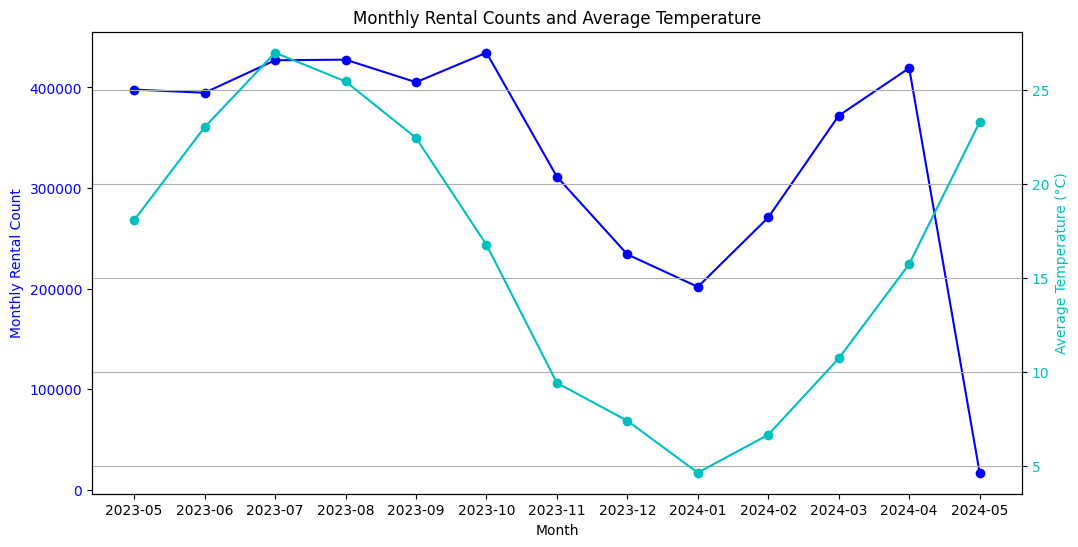

In [ ]:
filtered_data["started_day"] = pd.to_datetime(filtered_data["started_day"])
filtered_data["year_month"] = filtered_data["started_day"].dt.to_period("M")
monthly_rentals = filtered_data.groupby("year_month").size()
weather_frequency["date"] = pd.to_datetime(weather_frequency["date"])
weather_frequency["year_month"] = weather_frequency["date"].dt.to_period("M")
monthly_weather = (
    weather_frequency.groupby(["year_month", "icon"]).size().unstack(fill_value=0)
)

monthly_data = (
    weather_frequency.groupby("year_month")
    .agg({"pickup_counts": "sum", "temp": "mean"})
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Rental Count", color="b")
ax1.plot(
    monthly_data["year_month"].astype(str),
    monthly_data["pickup_counts"],
    color="b",
    marker="o",
)
ax1.tick_params(axis="y", labelcolor="b")

ax2 = ax1.twinx()
ax2.set_ylabel("Average Temperature (°C)", color="c")
ax2.plot(
    monthly_data["year_month"].astype(str), monthly_data["temp"], color="c", marker="o"
)
ax2.tick_params(axis="y", labelcolor="c")

plt.title("Monthly Rental Counts and Average Temperature")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

This plot shows the total bike rentals for each month alongside the average monthly temperature. By displaying rentals and temperature on separate y-axes, we can observe the relationship between seasonal temperature changes and bike usage.
We can see higher rentals in warmer months, revealing the seasonal nature of bike-sharing demand. Rental counts peaking during warmer months and declining in colder months.


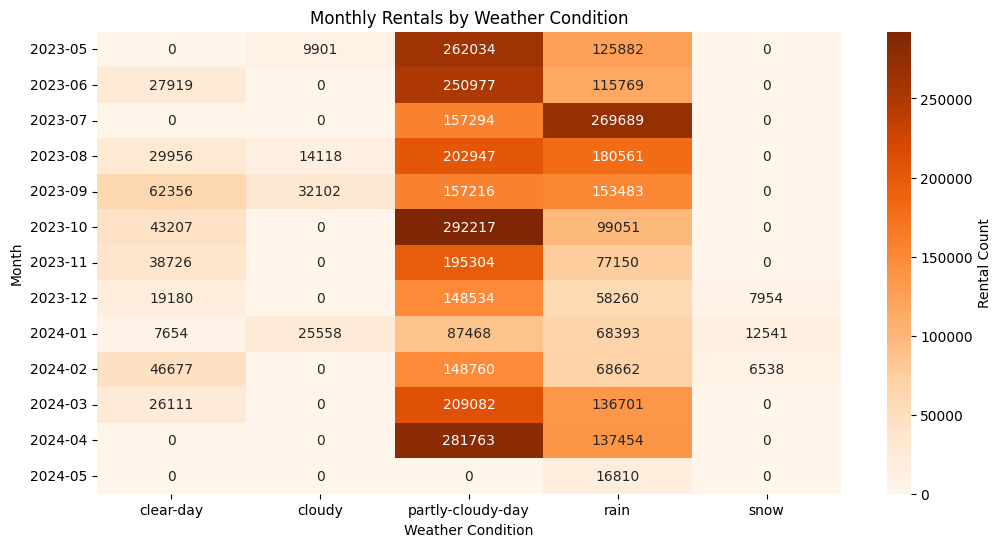

In [22]:
weather_frequency["year_month"] = weather_frequency["date"].dt.to_period("M")
monthly_weather_rentals = (
    weather_frequency.groupby(["year_month", "icon"])["pickup_counts"]
    .sum()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    monthly_weather_rentals,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar_kws={"label": "Rental Count"},
)
plt.xlabel("Weather Condition")
plt.ylabel("Month")
plt.title("Monthly Rentals by Weather Condition")
plt.show()


People rent the most bikes on partly cloudy and clear days, especially in warmer months like April, May, August, and October.
Rentals go down when it rains, but there are still a fair number of rentals in certain months. People are more likely to rent bikes on clear and partly cloudy days, and rentals drop on rainy days and even more on snowy days.


#### Weekly Trends in Rentals


/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/2134913529.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_trends = detail_frequency.groupby("day_of_week").size()


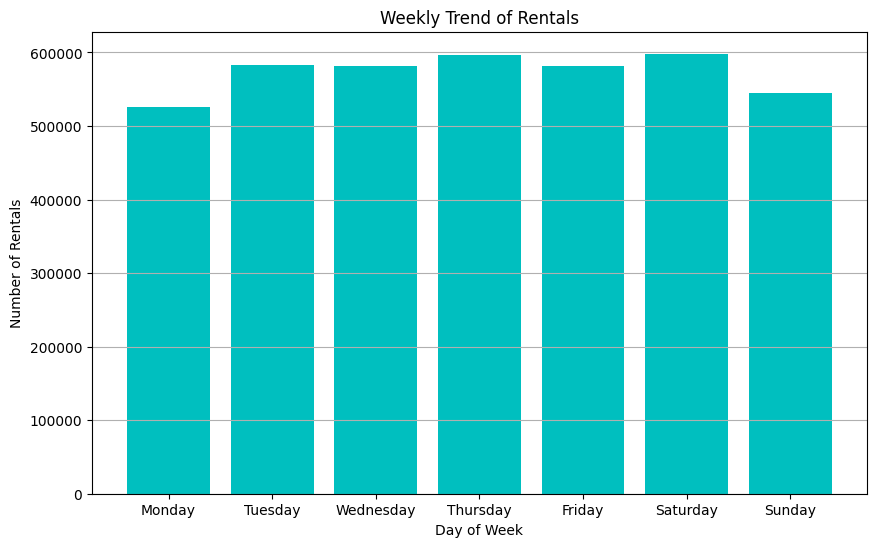

In [ ]:
filtered_data["started_at"] = pd.to_datetime(filtered_data["started_at"])
filtered_data["day_of_week"] = filtered_data["started_at"].dt.day_name()
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
filtered_data["day_of_week"] = pd.Categorical(
    filtered_data["day_of_week"], categories=day_order, ordered=True
)
weekly_trends = filtered_data.groupby("day_of_week").size()


plt.figure(figsize=(10, 6))
plt.bar(weekly_trends.index, weekly_trends, color="c")
plt.title("Weekly Trend of Rentals")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rentals")
plt.grid(axis="y")
plt.show()


The relatively even distribution of rentals from Tuesday to Saturday implies that biking is consistently popular on these days. There is a noticeable drop in rentals on Sunday and Monday compared to the other days.


#### Hourly Trend in Rentals


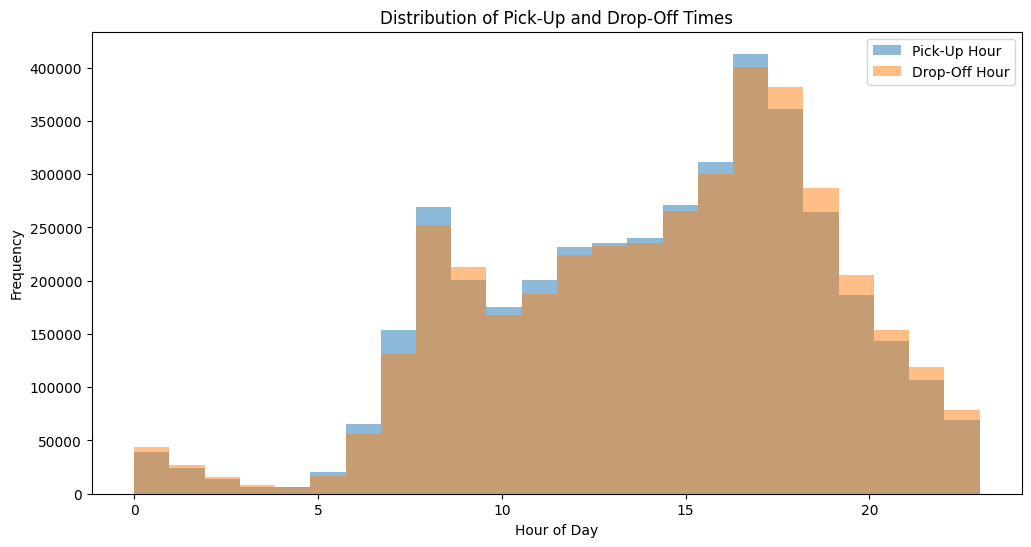

In [ ]:
filtered_data["started_at"] = pd.to_datetime(filtered_data["started_at"])
filtered_data["ended_at"] = pd.to_datetime(filtered_data["ended_at"])

filtered_data["start_hour"] = filtered_data["started_at"].dt.hour
filtered_data["end_hour"] = filtered_data["ended_at"].dt.hour

plt.figure(figsize=(12, 6))
plt.hist(filtered_data["start_hour"], bins=24, alpha=0.5, label="Pick-Up Hour")
plt.hist(filtered_data["end_hour"], bins=24, alpha=0.5, label="Drop-Off Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.title("Distribution of Pick-Up and Drop-Off Times")
plt.legend()
plt.show()

We can see that bike rentals peak during morning (8-9 AM) and evening (4-6 PM) rush hours, suggesting high use for commuting. There’s moderate activity in the midday, likely for leisure, and minimal rentals late at night.


#### Pick-Up Station Activity by Time of Day


We then focused on pick-up station activity to understand location-based demand over time.

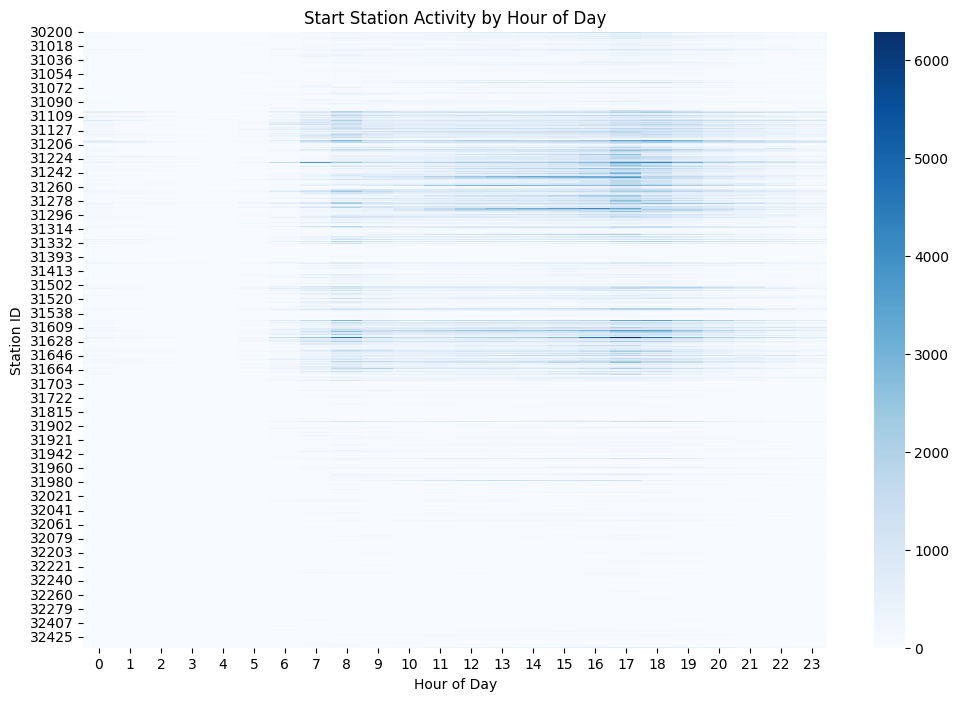

In [ ]:

station_activity = (
    filtered_data.groupby(["start_station_id", "start_hour"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(station_activity, cmap="Blues")
plt.xlabel("Hour of Day")
plt.ylabel("Station ID")
plt.title("Start Station Activity by Hour of Day")
plt.show()

Certain stations have consistently higher activity, as shown by the darker bands. These stations likely serve as central or high-demand locations in the network. Across all stations, activity is minimal from 10 PM to 5 AM, which is expected due to reduced travel during these hours.


### Top 10 Stations by Hourly Activity (Weekdays)
We drilled down into the busiest stations on weekdays to see the specific locations driving commuter traffic.

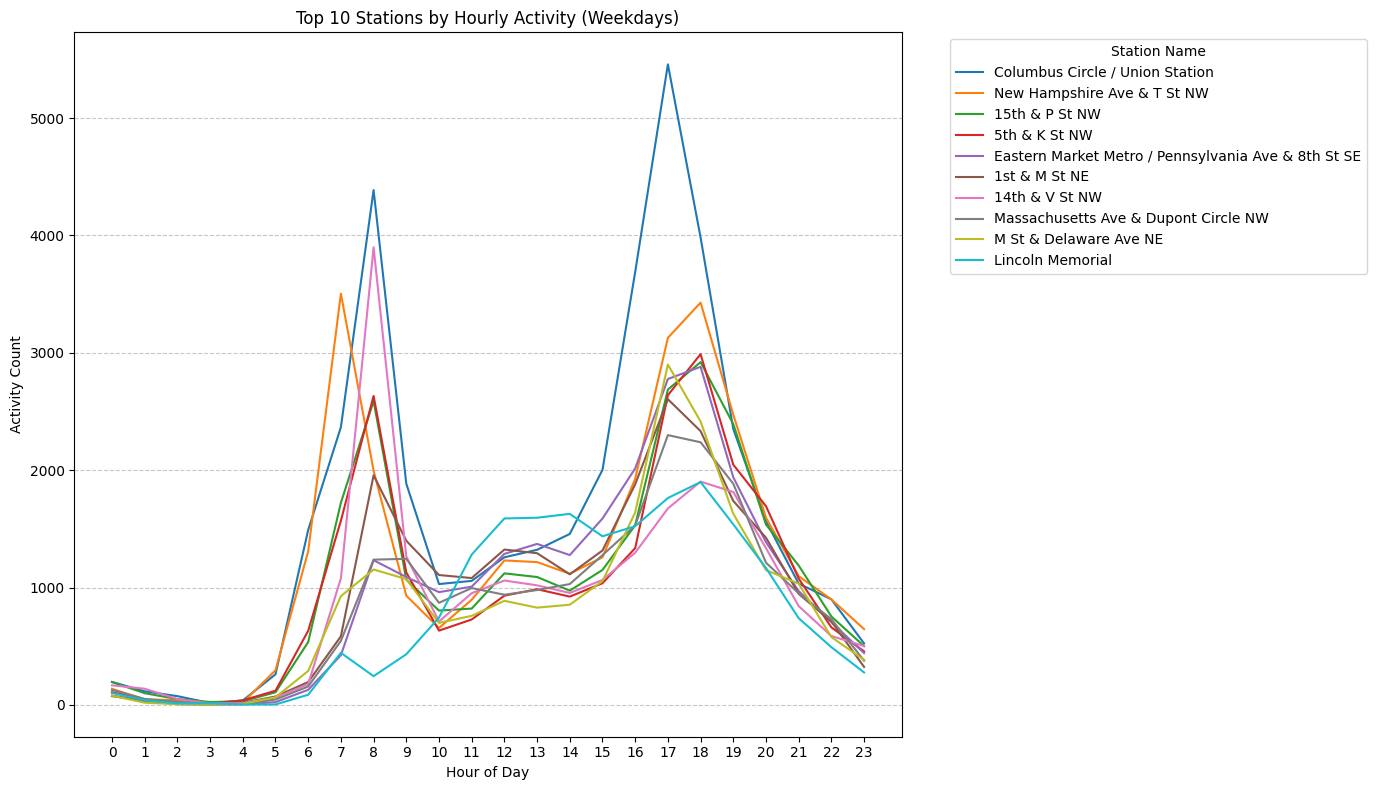

In [ ]:
weekday_data = filtered_data[filtered_data['started_at'].dt.weekday < 5]  # Monday=0, Sunday=6
station_hourly_weekdays = weekday_data.groupby(['start_station_name', 'start_hour']).size().unstack(fill_value=0)
top_stations_weekdays = weekday_data['start_station_name'].value_counts().nlargest(10).index
top_station_activity_weekdays = station_hourly_weekdays.loc[top_stations_weekdays]

plt.figure(figsize=(14, 8))
for station in top_station_activity_weekdays.index:
    plt.plot(top_station_activity_weekdays.columns, top_station_activity_weekdays.loc[station], label=station)

plt.xlabel("Hour of Day")
plt.ylabel("Activity Count")
plt.title("Top 10 Stations by Hourly Activity (Weekdays)")
plt.legend(title="Station Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


The top 10 stations show a clear pattern of high demand during the morning (around 8-9 AM) and evening (around 5-6 PM) commute hours. This pattern suggests these stations are heavily utilized for commuting. Across all top stations, there is minimal activity between late evening and early morning (from around 10 PM to 5 AM), which aligns with reduced demand outside typical commuting and daytime hours.

Certain stations, such as Columbus Circle / Union Station and New Hampshire Ave & T St NW, show significantly higher peaks, indicating they are major hubs in the network.

#### Distribution of Popular Pick-Up Locations

Finally, we provide a spatial map of popular pick-up points, tying together the temporal and geographical aspects of demand.


/Users/yidanchang/Desktop/FALL2024/SI618/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


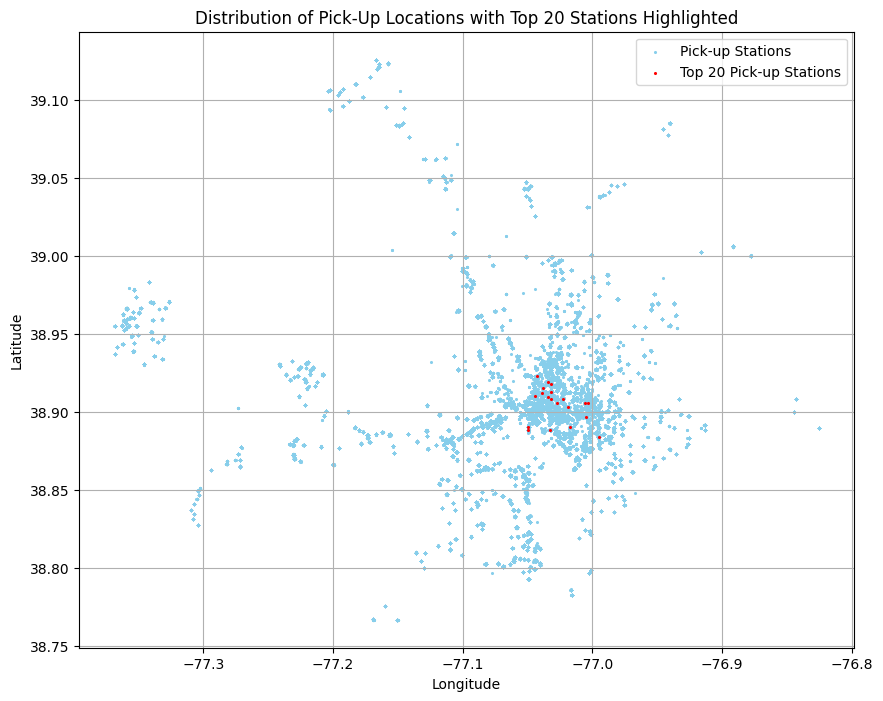

In [ ]:
top_20_start_stations = (
    filtered_data["start_station_name"].value_counts().nlargest(20).index
)


top_20_data = filtered_data[
    filtered_data["start_station_name"].isin(top_20_start_stations)
]
top_20_start_locations = (
    top_20_data[top_20_data["start_station_name"].isin(top_20_start_stations)]
    .groupby("start_station_name")[["start_lat", "start_lng"]]
    .mean()
)

plt.figure(figsize=(10, 8))
plt.scatter(
    filtered_data["start_lng"],
    filtered_data["start_lat"],
    color="skyblue",
    label="Pick-up Stations",
    s=1.5,
)

plt.scatter(
    top_20_start_locations["start_lng"],
    top_20_start_locations["start_lat"],
    color="red",
    label="Top 20 Pick-up Stations",
    s=1.5,
)


# for station, row in top_20_start_locations.iterrows():
#     plt.text(row["start_lng"], row["start_lat"], station, fontsize=6, color="navy", ha='right')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribution of Pick-Up Locations with Top 20 Stations Highlighted")
plt.legend()
plt.grid(True)
plt.show()

These pick-up stations are spread over a wide geographic region, but there is a noticeable concentration around the city center, suggesting a high-demand zone. The top 20 popular stations are located within the central cluster, confirming that the most-used stations are situated in areas with high demand.


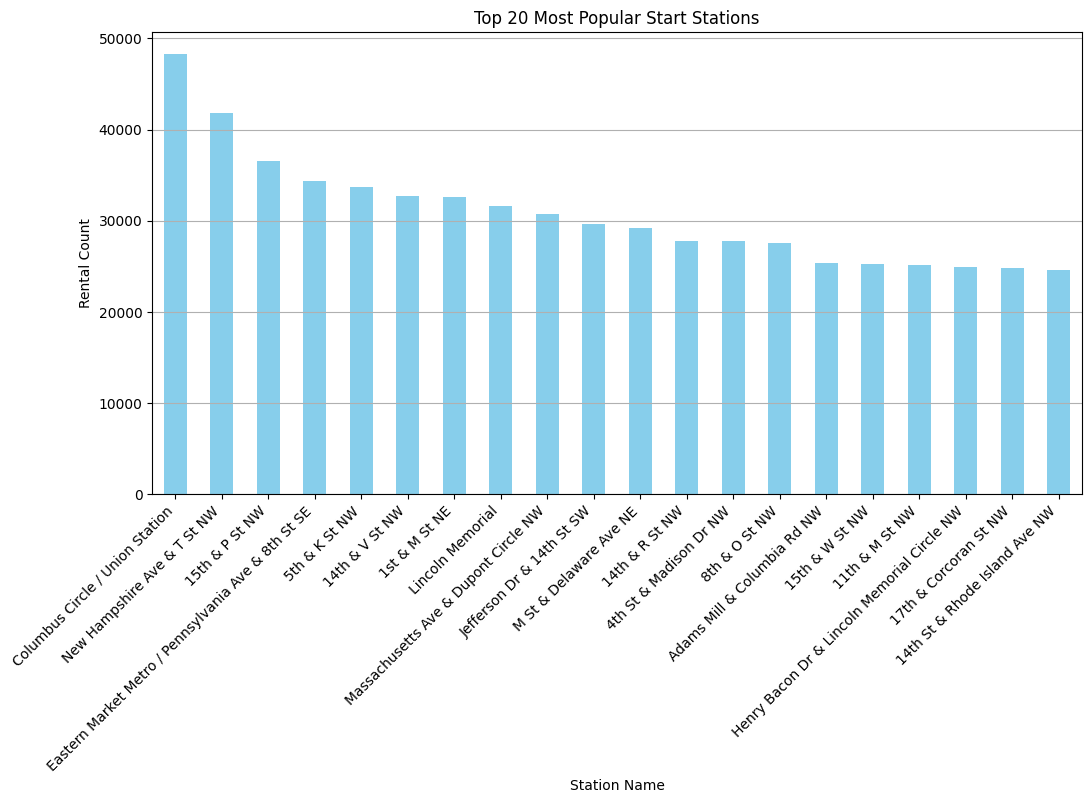

In [ ]:
top_stations = filtered_data["start_station_name"].value_counts().nlargest(20)
plt.figure(figsize=(12, 6))
top_stations.plot(kind="bar", color="skyblue")
plt.xlabel("Station Name")
plt.ylabel("Rental Count")
plt.title("Top 20 Most Popular Start Stations")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


This bar plot shows the top 20 most popular bike start stations. Many are near popular landmarks like the Lincoln Memorial and Union Station, indicating that both commuters and tourists frequently use these locations. Key streets like 14th St NW and Massachusetts Ave NW have several high-demand stations, suggesting these areas are major bike routes.


### User Behavior

In this section, we analyzed bike type preferences and explored how rental duration varies across different user segments.

#### Bike Type Usage


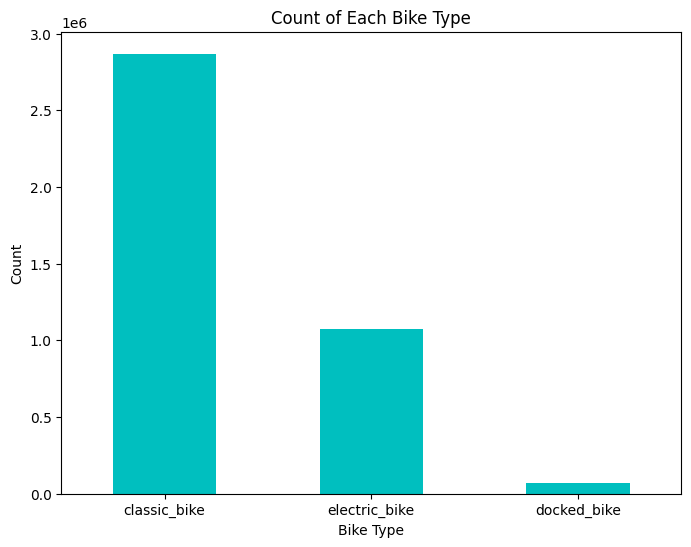

In [ ]:
plt.figure(figsize=(8, 6))
filtered_data["rideable_type"].value_counts().plot(kind="bar", color="c")
plt.xlabel("Bike Type")
plt.ylabel("Count")
plt.title("Count of Each Bike Type")
plt.xticks(rotation=0)
plt.show()

Classic bikes are the most popular, with nearly 3 million rentals, indicating they’re the primary choice for users. Electric bikes are used less frequently than classic bikes but still popular, while docked bikes are the least used.


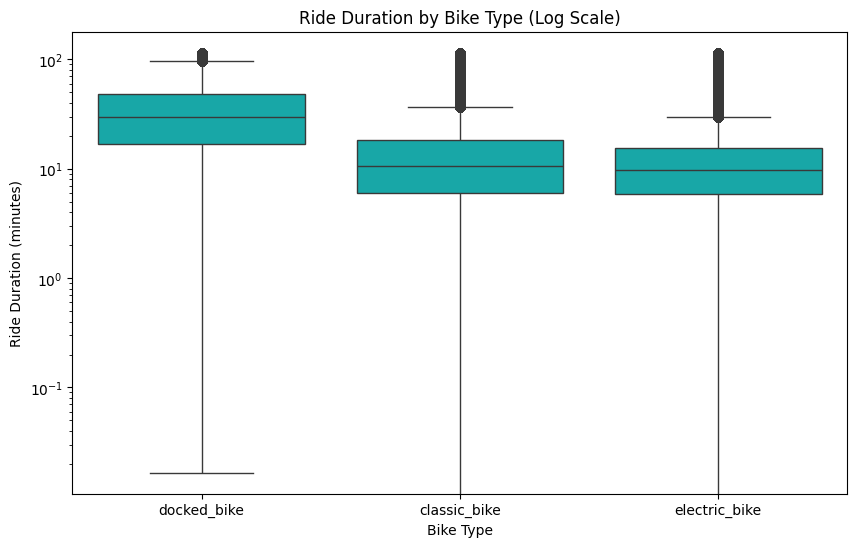

In [ ]:
filtered_data["ride_duration"] = (
    filtered_data["ended_at"] - filtered_data["started_at"]
).dt.total_seconds() / 60

quantile_99 = filtered_data["ride_duration"].quantile(0.99)
filtered_data = filtered_data[filtered_data["ride_duration"] <= quantile_99]

plt.figure(figsize=(10, 6))
sns.boxplot(x="rideable_type", y="ride_duration", data=filtered_data, color="c")
plt.yscale("log")
plt.title("Ride Duration by Bike Type (Log Scale)")
plt.xlabel("Bike Type")
plt.ylabel("Ride Duration (minutes)")
plt.show()


We can see that ride durations vary by bike type, with extreme outliers present, particularly for docked bikes. To focus on regular usage, we limited the data to the 99th percentile. Docked bikes generally have the longest ride durations, with more variability and occasional extreme outliers. Classic bikes and electric bikes have shorter, more consistent ride times, suggesting they are used for shorter trips.


#### Distribution of Ride Duration Across User Segments


/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/2566634153.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["duration"] = (
/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/2566634153.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["is_overnight"] = (
/Users/yidanchang/Desktop/FALL2024/SI618/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*in

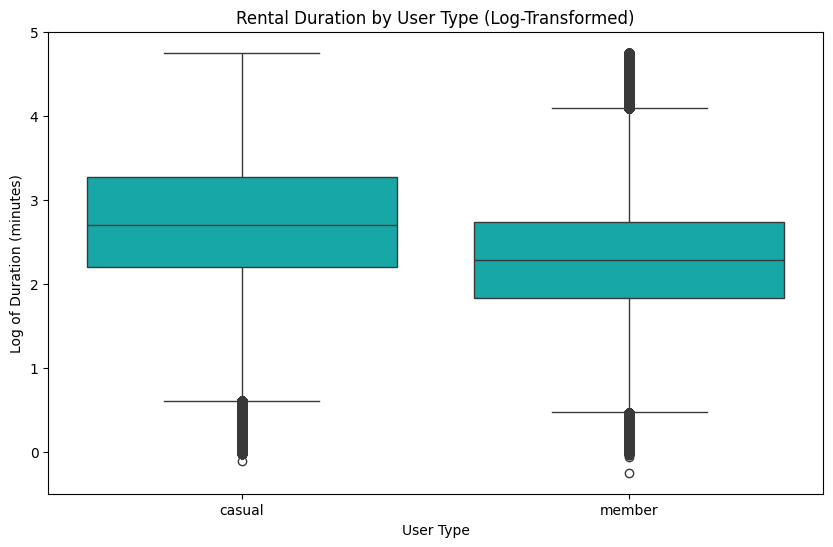

In [64]:
filtered_data["duration"] = (
    filtered_data["ended_at"] - filtered_data["started_at"]
).dt.total_seconds() / 60
filtered_data["is_overnight"] = (
    filtered_data["ended_at"].dt.date > filtered_data["started_at"].dt.date
)
overnight_count = filtered_data["is_overnight"].sum()
same_day_rentals = filtered_data[~filtered_data["is_overnight"]]

filtered_data["log_duration"] = np.log1p(filtered_data["duration"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x="member_casual", y="log_duration", color="c")
plt.title("Rental Duration by User Type (Log-Transformed)")
plt.xlabel("User Type")
plt.ylabel("Log of Duration (minutes)")
plt.show()

The data shows that casual users generally have longer ride durations compared to members, who tend to have shorter, more consistent trip times. Both casual users and members have some outliers with very long durations, though they are more common among casual users. These could be due to trips that were not properly ended in the system.


## Comparative Analysis


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### Weather and Usage Frequency


Our weather data covers an entire year, so we can categorize different weather conditions, seasons, temperatures, and precipitation to calculate bike rentals for different weather scenarios.

We have each station's rental data for that site at different times of the year and in different weather conditions. First we calculate the average value of usage for each site in different weather conditions.


In [66]:
weather = (
    weather_frequency.groupby("icon")[["pickup_counts", "dropoff_counts"]]
    .mean()
    .reset_index()
)
print(weather)

                icon  pickup_counts  dropoff_counts
0          clear-day      19.046134       18.823099
1             cloudy      19.254833       19.014380
2  partly-cloudy-day      20.157956       19.948999
3               rain      18.007153       17.789663
4               snow       8.356414        8.054096


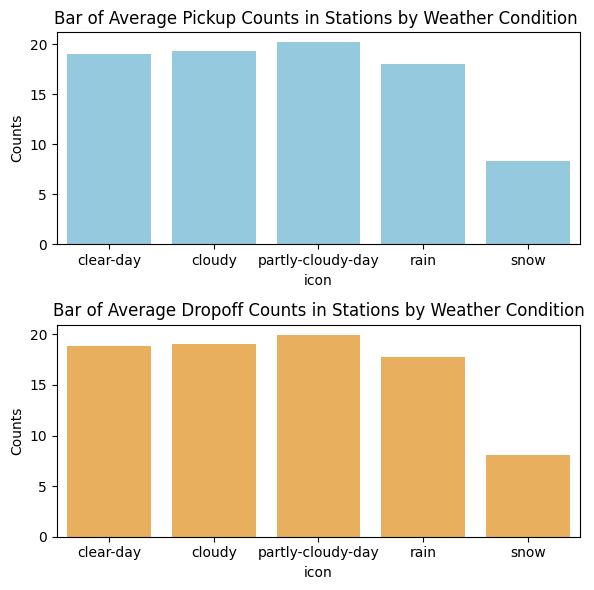

In [67]:
plt.figure(figsize=(6, 6))

plt.subplot(2, 1, 1)
sns.barplot(data=weather, x="icon", y="pickup_counts", color="skyblue")
plt.title("Bar of Average Pickup Counts in Stations by Weather Condition ")
plt.ylabel("Counts")

plt.subplot(2, 1, 2)
sns.barplot(data=weather, x="icon", y="dropoff_counts", color="#FFB347")
plt.title("Bar of Average Dropoff Counts in Stations by Weather Condition")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()

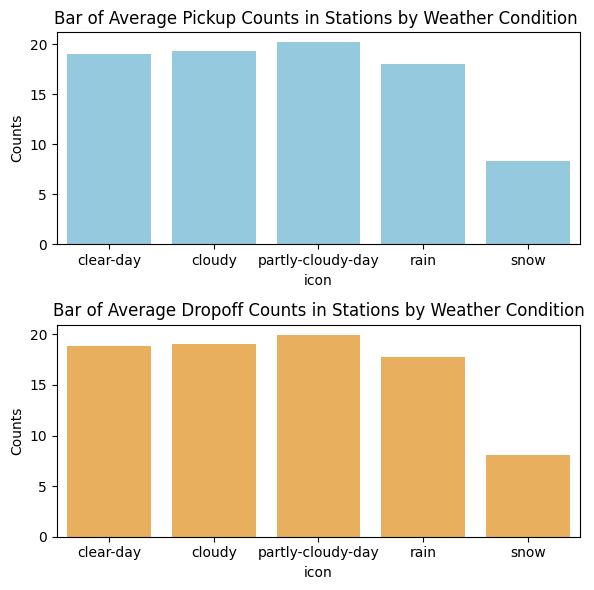

In [68]:
plt.figure(figsize=(6, 6))

plt.subplot(2, 1, 1)
sns.barplot(data=weather, x="icon", y="pickup_counts", color="skyblue")
plt.title("Bar of Average Pickup Counts in Stations by Weather Condition ")
plt.ylabel("Counts")
plt.subplot(2, 1, 2)
sns.barplot(data=weather, x="icon", y="dropoff_counts", color="#FFB347")
plt.title("Bar of Average Dropoff Counts in Stations by Weather Condition")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()

According to the bar plot, we can see that the highest average number of rentals is in partly-cloudy-day and the lowest average number of rentals is in snowy day. This may due to the fact that the weather conditions on partly-cloudy-day are more suitable for traveling by bike and people are willing to travel by bike in this scenarios. Whereas snow days have poorer road conditions and are not suitable for bicycles.


In [69]:
weather_ = weather_frequency[["icon", "pickup_counts", "dropoff_counts"]].sort_values(
    "icon"
)


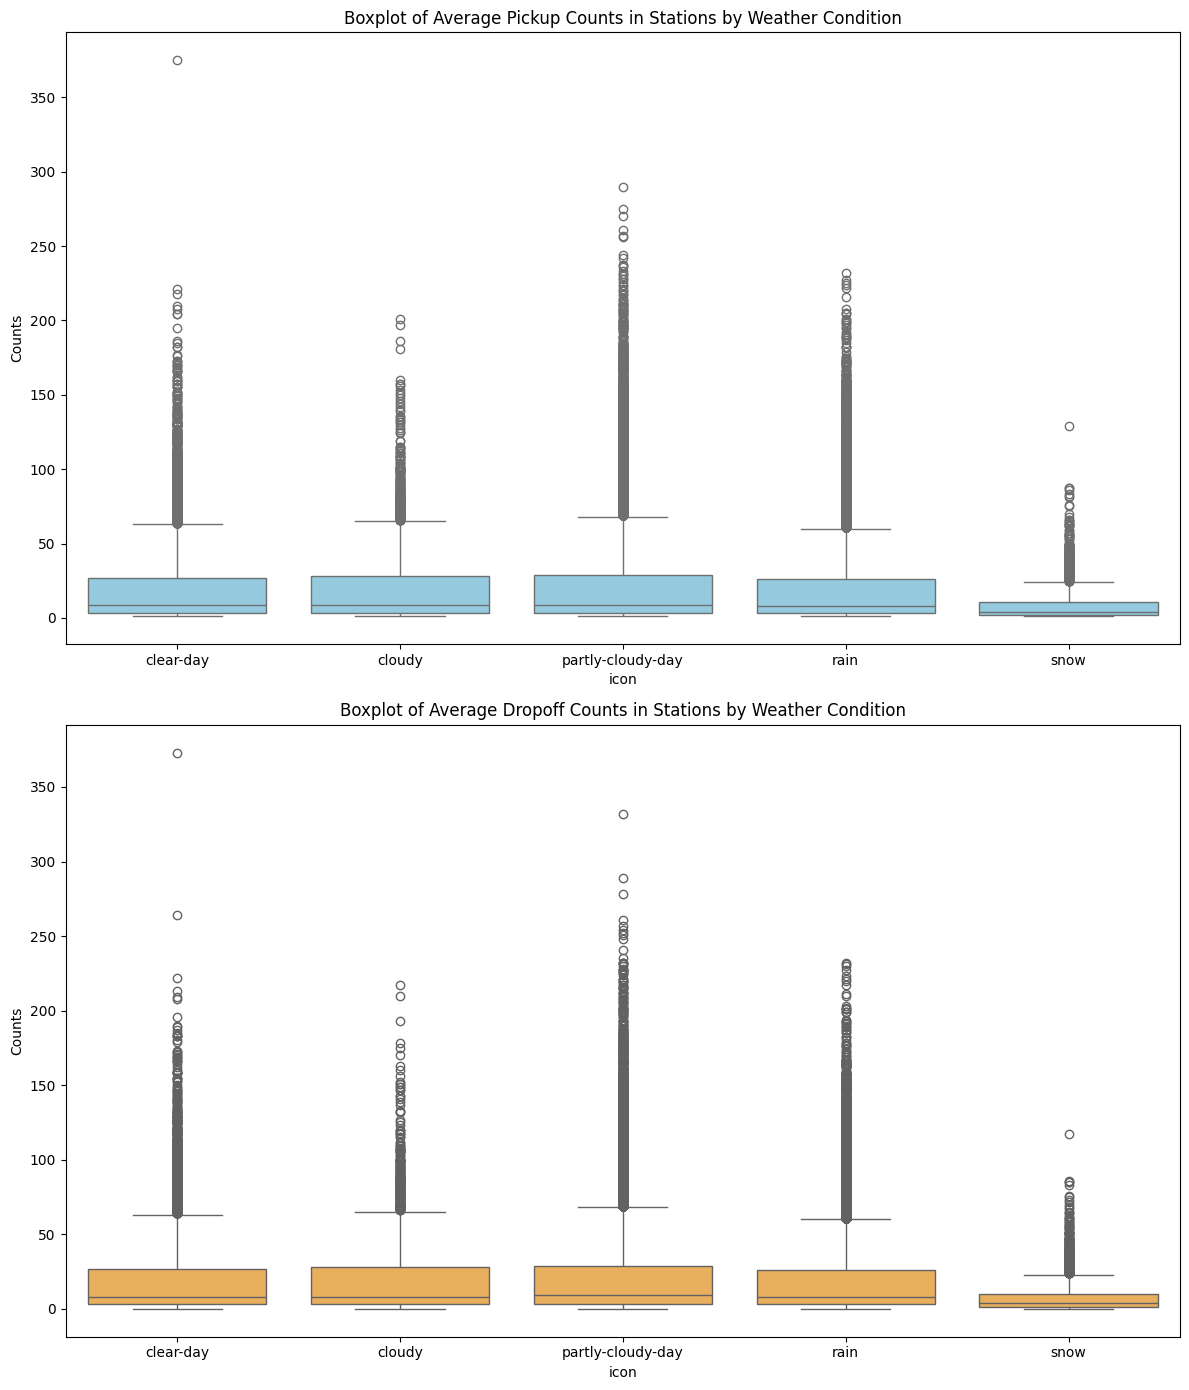

In [70]:
plt.figure(figsize=(12, 14))

plt.subplot(2, 1, 1)
sns.boxplot(data=weather_, x="icon", y="pickup_counts", color="skyblue")
plt.title("Boxplot of Average Pickup Counts in Stations by Weather Condition")
plt.ylabel("Counts")

plt.subplot(2, 1, 2)
sns.boxplot(data=weather_, x="icon", y="dropoff_counts", color="#FFB347")
plt.title("Boxplot of Average Dropoff Counts in Stations by Weather Condition")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()


Based on the results of barplots and boxplots, we can probably see that there is a significant difference in the status of bicycle rentals between snowy weather and other weather conditions. But for other weather conditions, we can't clearly find the difference between them. In order to get better results, we should do some statistical analysis such as anova.


In [71]:
model_pickup = ols("pickup_counts ~ C(icon)", data=weather_).fit()
anova_summary_pickup = anova_lm(model_pickup)

model_dropoff = ols("dropoff_counts ~ C(icon)", data=weather_).fit()
anova_summary_dropoff = anova_lm(model_dropoff)

print("ANOVA Summary for Pickup Counts:")
print(anova_summary_pickup)

print("\nANOVA Summary for Dropoff Counts:")
print(anova_summary_dropoff)

ANOVA Summary for Pickup Counts:
                df        sum_sq        mean_sq           F         PR(>F)
C(icon)        4.0  6.064559e+05  151613.983527  262.976647  6.785151e-226
Residual  225796.0  1.301782e+08     576.530217         NaN            NaN

ANOVA Summary for Dropoff Counts:
                df        sum_sq        mean_sq           F         PR(>F)
C(icon)        4.0  6.145131e+05  153628.269217  262.980935  6.727583e-226
Residual  225796.0  1.319056e+08     584.180252         NaN            NaN


In [72]:
tukey_pickup = pairwise_tukeyhsd(
    endog=weather_["pickup_counts"], groups=weather_["icon"], alpha=0.05
)
print("Tukey HSD Results for Pickup Counts:")
print(tukey_pickup)

tukey_dropoff = pairwise_tukeyhsd(
    endog=weather_["dropoff_counts"], groups=weather_["icon"], alpha=0.05
)
print("\nTukey HSD Results for Dropoff Counts:")
print(tukey_dropoff)

Tukey HSD Results for Pickup Counts:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1            group2      meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------
        clear-day            cloudy   0.2087 0.9871  -0.9236    1.341  False
        clear-day partly-cloudy-day   1.1118    0.0   0.5579   1.6658   True
        clear-day              rain   -1.039    0.0  -1.6064  -0.4716   True
        clear-day              snow -10.6897    0.0 -11.9534  -9.4261   True
           cloudy partly-cloudy-day   0.9031 0.1133  -0.1203   1.9265  False
           cloudy              rain  -1.2477 0.0085  -2.2785  -0.2169   True
           cloudy              snow -10.8984    0.0 -12.4273  -9.3696   True
partly-cloudy-day              rain  -2.1508    0.0  -2.4464  -1.8552   True
partly-cloudy-day              snow -11.8015    0.0 -12.9687 -10.6344   True
             rain              snow  -9

Based on the results of the ANOVA, we found that at least one group had significantly different results from the others. That is, at least in one weather condition, bicycle rentals showed a significant difference from those in other weather scenarios.

In order to further explore in which weather conditions the number of rentals was significantly different, we used the TukeyHSD method to perform the POST-HOC analysis of the ANOVA.
For pickup counts, the groups that showed significant differences at the 0.05 level were:

- clear-day and partly-cloudy-day
- clear-day and rain
- clear-day and snow
- cloudy and rain
- cloudy and snow
- partly-cloudy-day and rain
- partly-cloudy-day and snow
- rain and snow

For dropoff counts, results are the same.

Based on the above analysis, we can primarily conclude that partly-cloudy-day has the highest frequency of bike rentals. Snowy day has the least rental frequency. Bicycle rental frequency in most cases varies across weather scenario categories.


### Season and Frequency Usage.


We can analyze whether seasonal differences lead to differences in bicycle rentals by dividing the time of year into four seasons. Unlike weather scenarios, the seasonal categorization affects bikeshare by not only the temperature and precipitation conditions, but also the activity patterns of people at different times of the year.

In our analysis:

- March, April, May are regarded as spring.
- June, July, August are regarded as summer.
- September, October, November are regarded as autumn.
- December, January, February are regarded as winter.


In [73]:
def assign_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    elif month in [12, 1, 2]:
        return "Winter"


weather_frequency["date"] = pd.to_datetime(weather_frequency["date"], errors="coerce")
weather_frequency["month"] = weather_frequency["date"].dt.month
weather_frequency["season_tag"] = weather_frequency["month"].apply(assign_season)

In [74]:
season_ = weather_frequency[["season_tag", "pickup_counts", "dropoff_counts"]]
season = (
    season_.groupby("season_tag")[["pickup_counts", "dropoff_counts"]]
    .mean()
    .reset_index()
)

In [75]:
season = season.loc[[1, 2, 0, 3], :]
print(season)

  season_tag  pickup_counts  dropoff_counts
1     Spring      20.498776       20.276743
2     Summer      21.146151       20.968600
0       Fall      20.309761       20.090482
3     Winter      13.781254       13.535713


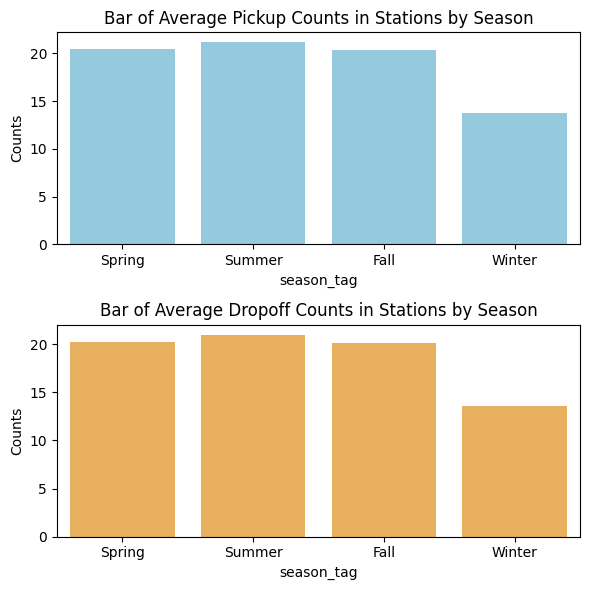

In [76]:
plt.figure(figsize=(6, 6))

plt.subplot(2, 1, 1)
sns.barplot(data=season, x="season_tag", y="pickup_counts", color="skyblue")
plt.title("Bar of Average Pickup Counts in Stations by Season")
plt.ylabel("Counts")

plt.subplot(2, 1, 2)
sns.barplot(data=season, x="season_tag", y="dropoff_counts", color="#FFB347")
plt.title("Bar of Average Dropoff Counts in Stations by Season")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()

According to the bar plot, we can see that the highest average number of rentals is in summer and the lowest average number of rentals is in winter. This may due to the fact that the weather conditions on summer are more suitable for traveling by bike. Whereas winter has a lot of snowy days which lead to poorer road conditions and are not suitable for bicycles.


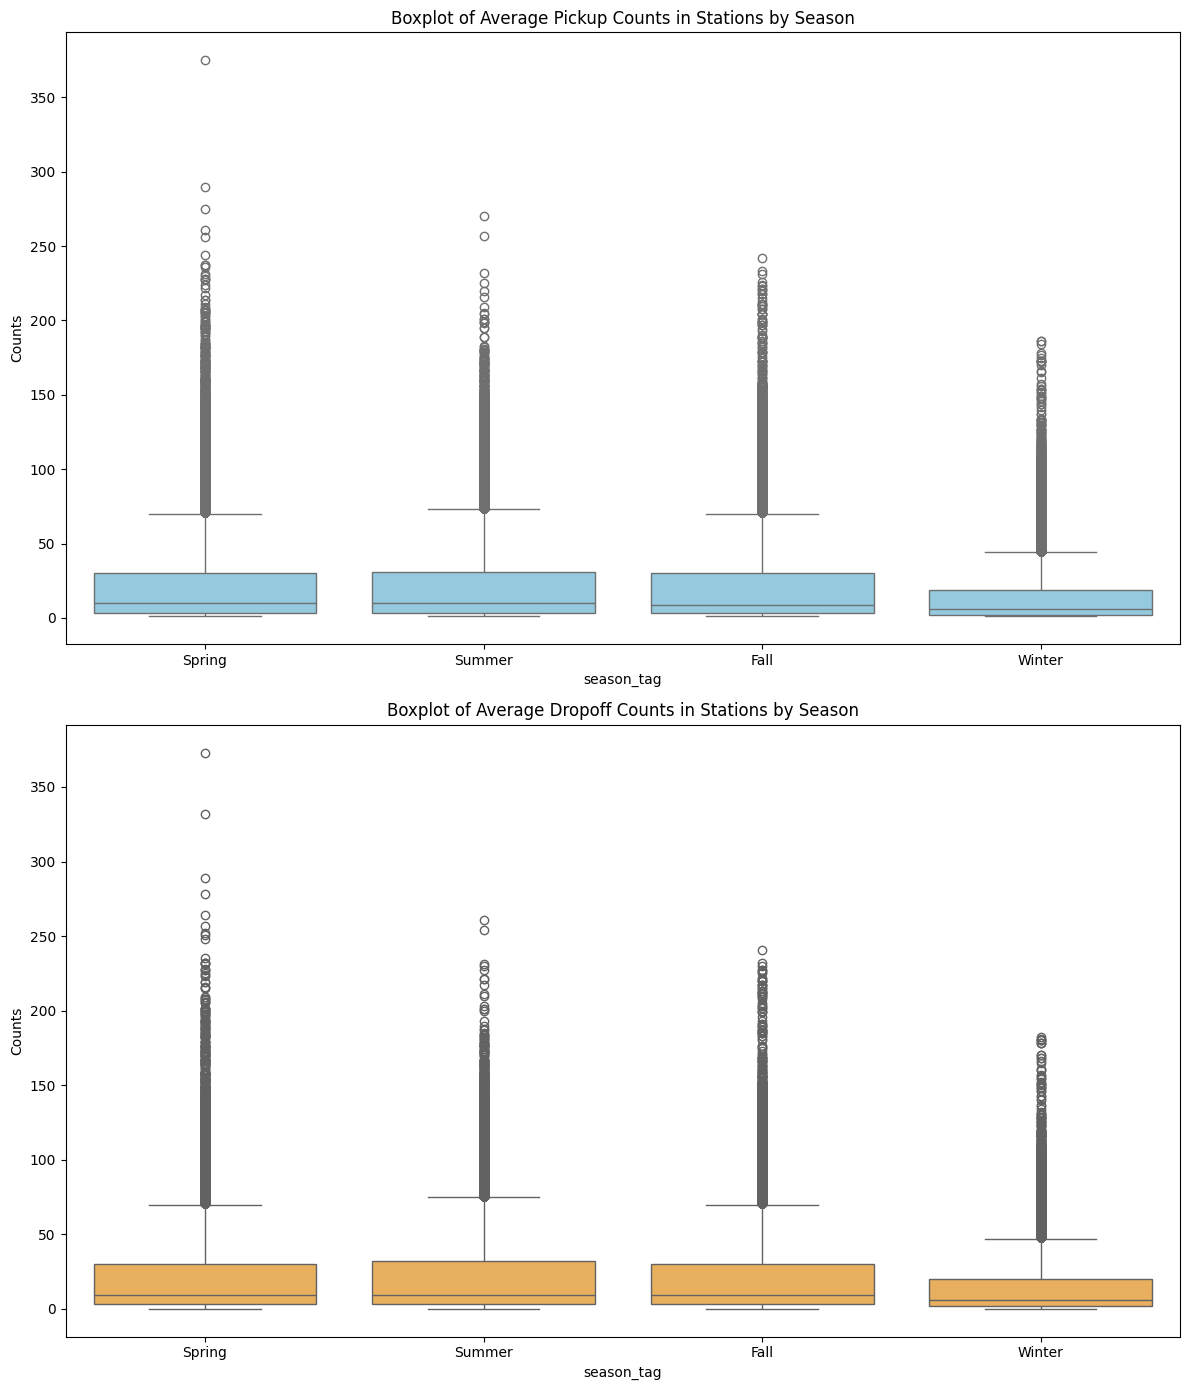

In [77]:
plt.figure(figsize=(12, 14))

plt.subplot(2, 1, 1)
sns.boxplot(data=season_, x="season_tag", y="pickup_counts", color="skyblue")
plt.title("Boxplot of Average Pickup Counts in Stations by Season")
plt.ylabel("Counts")

plt.subplot(2, 1, 2)
sns.boxplot(data=season_, x="season_tag", y="dropoff_counts", color="#FFB347")
plt.title("Boxplot of Average Dropoff Counts in Stations by Season")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()

Based on the results of barplots and boxplots, we can probably see that there is a significant difference in the status of bicycle rentals between winter and other weather conditions. But for other season, we can't clearly find the difference between them. In order to get better results, we should do some statistical analysis such as anova.


In [78]:
model_pickup = ols("pickup_counts ~ C(season_tag)", data=season_).fit()
anova_summary_pickup = anova_lm(model_pickup)

model_dropoff = ols("dropoff_counts ~ C(season_tag)", data=season_).fit()
anova_summary_dropoff = anova_lm(model_dropoff)

print("ANOVA Summary for Pickup Counts:")
print(anova_summary_pickup)

print("\nANOVA Summary for Dropoff Counts:")
print(anova_summary_dropoff)

ANOVA Summary for Pickup Counts:
                     df        sum_sq        mean_sq            F  PR(>F)
C(season_tag)       3.0  1.894934e+06  631644.564838  1106.553933     0.0
Residual       225797.0  1.288897e+08     570.821309          NaN     NaN

ANOVA Summary for Dropoff Counts:
                     df        sum_sq        mean_sq            F  PR(>F)
C(season_tag)       3.0  1.919025e+06  639675.055973  1105.938323     0.0
Residual       225797.0  1.306011e+08     578.400298          NaN     NaN


In [79]:
tukey_pickup = pairwise_tukeyhsd(
    endog=season_["pickup_counts"], groups=season_["season_tag"], alpha=0.05
)
print("Tukey HSD Results for Pickup Counts:")
print(tukey_pickup)

tukey_dropoff = pairwise_tukeyhsd(
    endog=season_["dropoff_counts"], groups=season_["season_tag"], alpha=0.05
)
print("\nTukey HSD Results for Dropoff Counts:")
print(tukey_dropoff)

Tukey HSD Results for Pickup Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Fall Spring    0.189 0.5348 -0.1723  0.5503  False
  Fall Summer   0.8364    0.0  0.4755  1.1973   True
  Fall Winter  -6.5285    0.0 -6.9027 -6.1543   True
Spring Summer   0.6474    0.0  0.2899  1.0049   True
Spring Winter  -6.7175    0.0 -7.0884 -6.3466   True
Summer Winter  -7.3649    0.0 -7.7354 -6.9944   True
----------------------------------------------------

Tukey HSD Results for Dropoff Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Fall Spring   0.1863 0.5528 -0.1774  0.5499  False
  Fall Summer   0.8781    0.0  0.5148  1.2414   True
  Fall Winter  -6.5548    0.0 -6.9314 -6.1781   True
Spring Summer   0.6919    0.0   0.332  1.0517   True
Spring Winter   -6.741 

Based on the results of the ANOVA, we found that at least one group had significantly different results from the others. That is, at least in one season, bicycle rentals showed a significant difference from those in other season.

In order to further explore in which season the number of rentals was significantly different, we used the TukeyHSD method to perform the POST-HOC analysis of the ANOVA.
For pickup counts, the groups that showed significant differences at the 0.05 level were:

- Fall and Summer
- Fall and Winter
- Spring and Summer
- Spring and Winter
- Summer and Winter

For dropoff counts, results are the same.

Based on the above analysis, we can primarily conclude that summertime has the highest frequency of bike rentals. Winter has the least rental frequency. Weather conditions and crowd activity patterns are similar in the spring and fall, so there is no significant difference in bike rentals between these two seasons.


### Subset Comparative


Based on the difference of bike share frequency in different weather conditions and different seasons that we obtained above, in order to show the results more clearly, we extracted two subsets of different time subsets from the data and did a comparative analysis of them.

We obtained two bike share subsets from the data:

- data in July 2023 (summer, few snowy days)
- data in January 2024 (winter, mostly snowy days)

We analyzed them for frequency of use, user profiles, and so on.


In [80]:
jan_w = weather_frequency.loc[weather_frequency["month"] == 1]
july_w = weather_frequency.loc[weather_frequency["month"] == 7]

filtered_data["started_at"] = pd.to_datetime(filtered_data["started_at"])
jan_d = filtered_data[filtered_data["started_at"].dt.month == 1]
july_d = filtered_data[filtered_data["started_at"].dt.month == 7]

/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/142076049.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["started_at"] = pd.to_datetime(filtered_data["started_at"])


In [81]:
print("For January:")
print(jan_w[["pickup_counts", "dropoff_counts"]].describe())

print("For July:")
print(july_w[["pickup_counts", "dropoff_counts"]].describe())

For January:
       pickup_counts  dropoff_counts
count   16454.000000    16454.000000
mean       12.253191       11.994287
std        15.615513       15.593908
min         1.000000        0.000000
25%         2.000000        2.000000
50%         6.000000        6.000000
75%        17.000000       17.000000
max       186.000000      170.000000
For July:
       pickup_counts  dropoff_counts
count   20180.000000    20180.000000
mean       21.158722       20.983102
std        25.901461       26.187720
min         1.000000        0.000000
25%         3.000000        3.000000
50%        10.000000        9.000000
75%        31.000000       32.000000
max       270.000000      261.000000


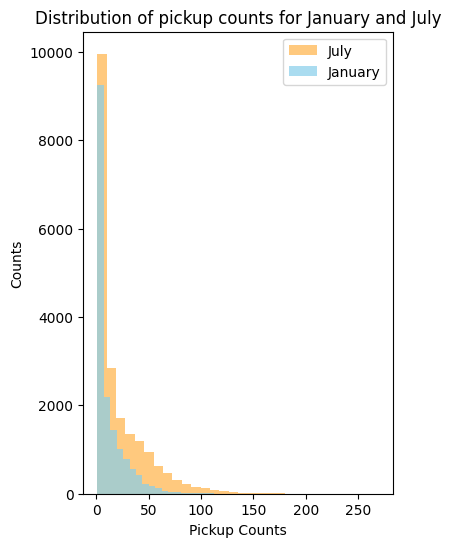

In [82]:
plt.figure(figsize=(4, 6))
plt.hist(
    july_w["pickup_counts"], bins=30, color="#FFB347", alpha=0.7, label="July"
)  # ,density=True)
plt.hist(
    jan_w["pickup_counts"], bins=30, color="skyblue", alpha=0.7, label="January"
)  # ,density=True)


plt.title("Distribution of pickup counts for January and July")
plt.xlabel("Pickup Counts")
plt.ylabel("Counts")

plt.legend()

plt.show()

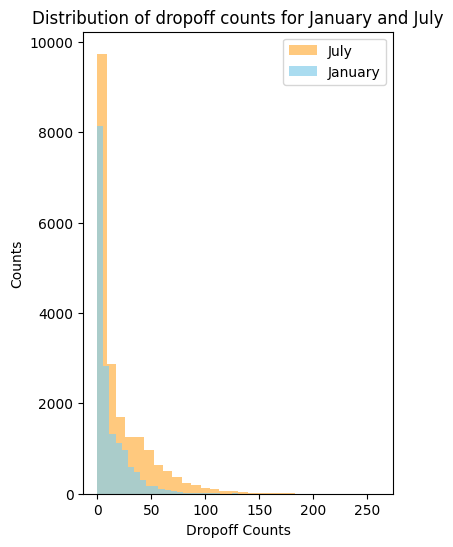

In [83]:
plt.figure(figsize=(4, 6))
plt.hist(
    july_w["dropoff_counts"], bins=30, color="#FFB347", alpha=0.7, label="July"
)  # ,density=True)
plt.hist(
    jan_w["dropoff_counts"], bins=30, color="skyblue", alpha=0.7, label="January"
)  # ,density=True)


plt.title("Distribution of dropoff counts for January and July")
plt.xlabel("Dropoff Counts")
plt.ylabel("Counts")

plt.legend()

plt.show()

Based on the results of our base statistics and the histograms, we can find a difference in bike shares between the two subsets. The numbers of pickup and dropoff in July are much larger than the numbers in January, which is in line with the conclusions we got in our previous analysis.


### Weekday/Weekend Analysis


We suspect that people's bike rentals may vary during on the weekday and on the weekend. Therefore, we divided the data into two groups and do the comparative analysis to see if there are some differences in the bike rental data in two time periods


In [84]:
weather_frequency["day_tag"] = weather_frequency["date"].dt.weekday.apply(
    lambda x: "weekday" if x < 5 else "weekend"
)
print(weather_frequency["day_tag"].value_counts())

day_tag
weekday    162359
weekend     63442
Name: count, dtype: int64


In [85]:
weekday = (
    weather_frequency.groupby("day_tag")[["pickup_counts", "dropoff_counts"]]
    .mean()
    .reset_index()
)
print(weekday)

   day_tag  pickup_counts  dropoff_counts
0  weekday      19.041796       18.818618
1  weekend      19.235711       19.041502


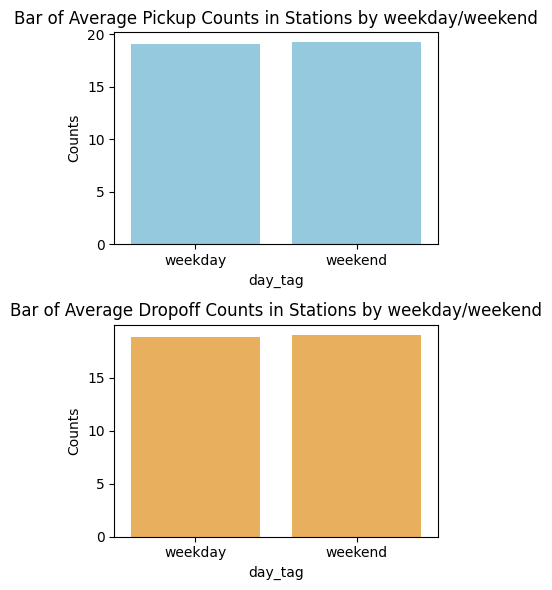

In [86]:
plt.figure(figsize=(4, 6))

plt.subplot(2, 1, 1)
sns.barplot(data=weekday, x="day_tag", y="pickup_counts", color="skyblue")
plt.title("Bar of Average Pickup Counts in Stations by weekday/weekend")
plt.ylabel("Counts")

plt.subplot(2, 1, 2)
sns.barplot(data=weekday, x="day_tag", y="dropoff_counts", color="#FFB347")
plt.title("Bar of Average Dropoff Counts in Stations by weekday/weekend")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()

In [87]:
weekday_ = weather_frequency[["pickup_counts", "dropoff_counts", "day_tag"]]

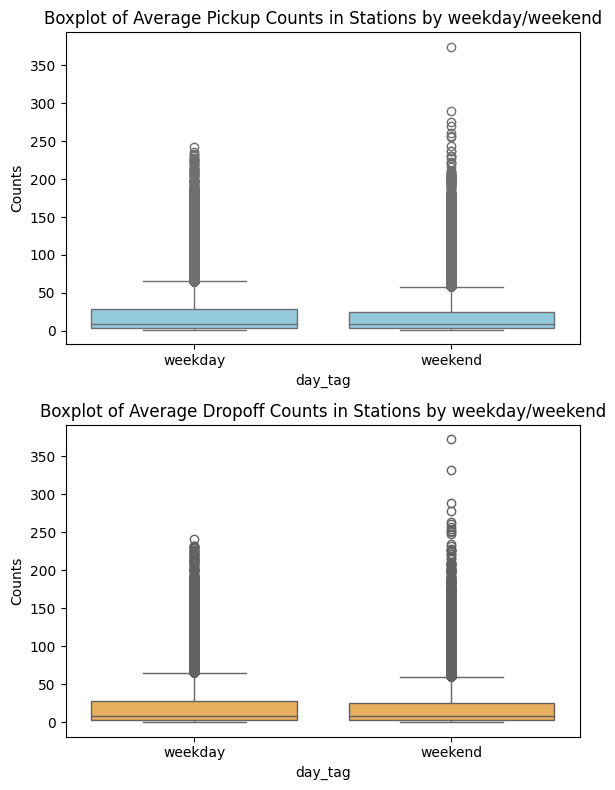

In [88]:
plt.figure(figsize=(6, 8))

plt.subplot(2, 1, 1)
sns.boxplot(data=weekday_, x="day_tag", y="pickup_counts", color="skyblue")
plt.title("Boxplot of Average Pickup Counts in Stations by weekday/weekend")
plt.ylabel("Counts")

plt.subplot(2, 1, 2)
sns.boxplot(data=weekday_, x="day_tag", y="dropoff_counts", color="#FFB347")
plt.title("Boxplot of Average Dropoff Counts in Stations by weekday/weekend")
plt.ylabel("Counts")

plt.tight_layout()
plt.show()

We can't see any difference just from the bar chart and boxplot. Therefore we need to perform statistical analysis such as ANOVA.


In [89]:
model_pickup = ols("pickup_counts ~ C(day_tag)", data=weekday_).fit()
anova_summary_pickup = anova_lm(model_pickup)

model_dropoff = ols("dropoff_counts ~ C(day_tag)", data=weekday_).fit()
anova_summary_dropoff = anova_lm(model_dropoff)

print("ANOVA Summary for Pickup Counts:")
print(anova_summary_pickup)

print("\nANOVA Summary for Dropoff Counts:")
print(anova_summary_dropoff)

ANOVA Summary for Pickup Counts:
                  df        sum_sq      mean_sq         F    PR(>F)
C(day_tag)       1.0  1.715341e+03  1715.341497  2.961566  0.085267
Residual    225799.0  1.307830e+08   579.200783       NaN       NaN

ANOVA Summary for Dropoff Counts:
                  df        sum_sq      mean_sq         F    PR(>F)
C(day_tag)       1.0  2.266141e+03  2266.141403  3.861311  0.049413
Residual    225799.0  1.325178e+08   586.883960       NaN       NaN


According to anova results, we can find that at the level of alpha=0.1, the data for both pickup and dropoff are significantly different at different times of the week.


In [90]:
tukey_pickup = pairwise_tukeyhsd(
    endog=weekday_["pickup_counts"], groups=weekday_["day_tag"], alpha=0.1
)
print("Tukey HSD Results for Pickup Counts:")
print(tukey_pickup)

tukey_dropoff = pairwise_tukeyhsd(
    endog=weekday_["dropoff_counts"], groups=weekday_["day_tag"], alpha=0.1
)
print("\nTukey HSD Results for Dropoff Counts:")
print(tukey_dropoff)

Tukey HSD Results for Pickup Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.10 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
weekday weekend   0.1939 0.0853 0.0086 0.3793   True
----------------------------------------------------

Tukey HSD Results for Dropoff Counts:
Multiple Comparison of Means - Tukey HSD, FWER=0.10 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
weekday weekend   0.2229 0.0494 0.0363 0.4095   True
----------------------------------------------------


Based on the results of tukeyHSD, we can see that the number of bike rentals will be slightly higher on weekends than during the week. This may be because for some people who don't ride bicycles for commuting during the weekday, they use bicycles in more scenarios on weekends, such as as part of excursions, sports, and so on. However this difference is only more pronounced at the 0.1 level. If we set the alpha to 0.05, then only the difference between groups for dropoff is significant. For the discrepancy between pickup and dropoff results, we speculate that it is because some people pick up bikes during the weekday and return them on the weekend.


## Multivariate Analysis


### Bike Type and Member Type


In our detail records, we find that the data records the type of bike being rented that corresponds to each record, as well as the VIP status of the user who rented this bike. So we made a pivot table and heatmap to observe if there is any correlation between them.

We normalized all the results when performing the calculations. The values shown in the pivot table and heatmap are the current category as a percentage of the total.


In [91]:
member_bike = pd.crosstab(
    filtered_data["member_casual"], filtered_data["rideable_type"], margins=True
)

total_sum = member_bike.loc["All", "All"]
member_bike_normalized = member_bike / total_sum * 100
print(member_bike_normalized)


rideable_type  classic_bike  docked_bike  electric_bike         All
member_casual                                                      
casual            24.608448     1.565301      10.586116   36.759866
member            46.921374     0.000000      16.318760   63.240134
All               71.529822     1.565301      26.904877  100.000000


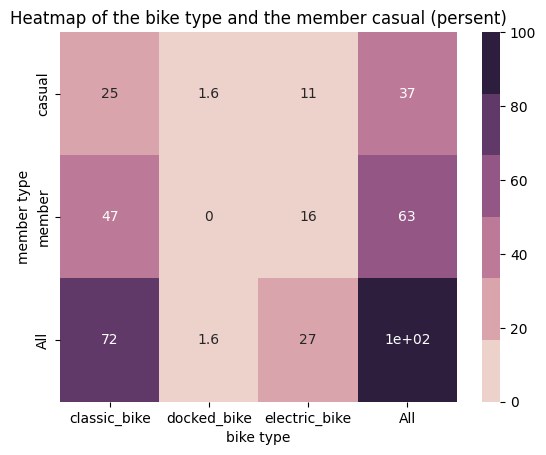

In [92]:
sns.heatmap(member_bike_normalized, annot=True, cmap=sns.cubehelix_palette())
plt.title("Heatmap of the bike type and the member casual (persent)")
plt.xlabel("bike type")
plt.ylabel("member type")
plt.show()

This is an interesting result. We can see that the most records were recorded for renting classic bikes, followed by electric bikes, and finally docked bikes. This may because that for this bikeshare company, the most placed bikes that were classic bikes.

We also find that there are more member users than casual users among those who rented classic bikes and e-bikes. But for docked bikes, only casual users pickup them.


### Rent Duration and Member Type


We want to observe the distribution of the bike rental duration for different types of users.

In this step, we performed a simple filter on the length of rentals thereby removing the excessively large portion of the data. Since our two user groups have different totals, we normalized the histograms so that we could better see the difference in their distributions.


In [93]:
filtered_data["started_at"] = pd.to_datetime(filtered_data["started_at"])
filtered_data["ended_at"] = pd.to_datetime(filtered_data["ended_at"])


filtered_data["rent_duration"] = (
    filtered_data["ended_at"] - filtered_data["started_at"]
)
filtered_data["rent_duration"] = filtered_data["rent_duration"].dt.total_seconds()

/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/3357745404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["started_at"] = pd.to_datetime(filtered_data["started_at"])
/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/3357745404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["ended_at"] = pd.to_datetime(filtered_data["ended_at"])
/var/folders/p5/grng0bpx24988f1v2318bx6w0000gn/T/ipykernel_2364/3357745404.py:5: SettingWithCopyWarning: 
A value 

In [94]:
member_duration = filtered_data.loc[
    filtered_data["member_casual"] == "member", ["rent_duration", "member_casual"]
]
casual_duration = filtered_data.loc[
    filtered_data["member_casual"] == "casual", ["rent_duration", "member_casual"]
]

threshold_member = member_duration["rent_duration"].quantile(0.99)
threshold_casual = casual_duration["rent_duration"].quantile(0.99)

filtered_member_duration = member_duration[
    (member_duration["rent_duration"] <= threshold_member)
    & (member_duration["rent_duration"] >= 0)
]
filtered_casual_duration = casual_duration[
    (casual_duration["rent_duration"] <= threshold_casual)
    & (casual_duration["rent_duration"] >= 0)
]


In [95]:
filtered_member_duration.head()

,rent_duration,member_casual
1,943.0,member
2,787.0,member
3,786.0,member
5,194.0,member
6,1376.0,member


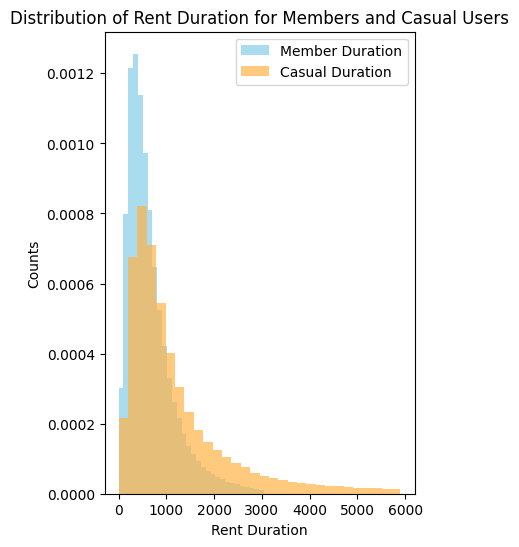

In [96]:
plt.figure(figsize=(4, 6))

plt.hist(
    filtered_member_duration["rent_duration"],
    bins=30,
    color="skyblue",
    alpha=0.7,
    label="Member Duration",
    density=True,
)
plt.hist(
    filtered_casual_duration["rent_duration"],
    bins=30,
    color="#FFB347",
    alpha=0.7,
    label="Casual Duration",
    density=True,
)

plt.title("Distribution of Rent Duration for Members and Casual Users")
plt.xlabel("Rent Duration")
plt.ylabel("Counts")

plt.legend()

plt.show()

Based on the results we can find that member users rent mainly distribute in shorter duration intervals and casual users prefer to rent for longer durations. This may because that for this company's bike rental service, non-members get a better deal for longer rent duration, which may be due to the presence of a starting price. Once they become a member, their short-term rentals are cheaper.


## Synthesis


In our analysis, we focused on understanding bike-sharing patterns in relation to weather, seasons, user behavior, and spatial demand. The insights gained from statistical and correlation analyses lay the groundwork for future predictive modeling.

**Temporal Demand Patterns**

- Hourly and Weekly Patterns：Bike rentals peak during commuting hours (8-9 AM and 4-6 PM). This pattern is consistent across the busiest stations, suggesting that a significant portion of demand is driven by commuters. Saturdays see the highest average ride counts, likely due to increased leisure activities, while Mondays have the lowest, likely driven by routine work commutes.
- Monthly and Seasonal Patterns: There’s a clear trend of higher rentals on weekends and in warmer months (July, August, October).
- ANOVA and Tukey HSD tests reveal notable differences in ride durations by day, with weekends and Fridays showing longer average ride times than other weekdays. This pattern indicates a shift toward recreational use on weekends.

**Weather Impact**

- Partly cloudy and clear days see the highest bike rentals, as these conditions are generally comfortable for cycling. Rainy and snowy days significantly reduce bike usage, underscoring the role of weather in affecting outdoor activity levels.
- A positive correlation between temperature and ride counts suggests that warmer days are associated with more rentals, though temperature alone does not fully account for ride duration variability.

**Geographical Demand Distribution**

- Chi-square tests confirm that bike type distribution varies across stations, suggesting a relationship between station location and bike type preferences, potentially influenced by user needs or operational strategies.
- Stations near landmarks and transit hubs like Union Station exhibit high demand, particularly during commute hours, highlighting these locations as critical points in the bike-sharing network where availability is essential.

**User Behavior**

- Classic bikes are the most popular among users, while docked bikes are primarily used by casual riders.
- Casual users tend toward longer ride durations, likely for recreational use, while members generally take shorter trips.

These findings provide a foundation for improving bike-sharing services:

- Ensure sufficient bikes at high-demand stations and during peak hours can enhance service efficiency.
- Adjust bike availability based on forecasted weather and seasonal patterns can help align supply with demand fluctuations.
- Promote longer rental options and electric bikes to casual users, especially on weekends.



## Reflection


**Challenges and Solutions**

- A major challenge was data quality, particularly with outliers in ride durations (e.g., negative or unusually long values). We excluded the top 1% of extreme durations to focus on regular usage patterns, ensuring that outliers didn’t distort our findings.
- Another challenge involved aligning data from multiple sources (weather, rental, and spatial data) with different time scales and formats. We standardized time formats and synchronized timestamps, allowing accurate comparisons, particularly for hourly analyses.

**Limitations**

- While temperature was a statistically significant factor for ride counts, it explained only a small portion of the variation in rental duration. This suggests that other factors, possibly unmeasured in our dataset, impact demand more substantially.

**Future Work**

- Our next step is to create a predictive model that uses weather, user type, and location data to forecast demand. This would allow operators to anticipate rental fluctuations more accurately, enabling proactive adjustments to bike availability and maintenance schedules.
